In [1]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns

AttributeError: module 'numpy._globals' has no attribute '_signature_descriptor'

ImportError: numpy._core.multiarray failed to import

In [2]:
final_df=pd.read_csv('Final_Cleaned_Dataset_with_sorting.csv')

In [3]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6727451 entries, 0 to 6727450
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   event_time            str    
 1   event_type            str    
 2   product_id            int64  
 3   category_id           int64  
 4   category_code         str    
 5   brand                 str    
 6   price                 float64
 7   user_id               int64  
 8   user_session          str    
 9   category_code_filled  str    
 10  brand_filled          str    
 11  hour                  int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 615.9 MB


In [3]:
final_df.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19


In [4]:
final_df['price']

0           69.17
1          458.25
2          458.25
3          716.76
4          716.76
            ...  
6727446     32.15
6727447     32.15
6727448    244.54
6727449     82.63
6727450    398.98
Name: price, Length: 6727451, dtype: float64

Generating Supply vs Demand Price Distributions...


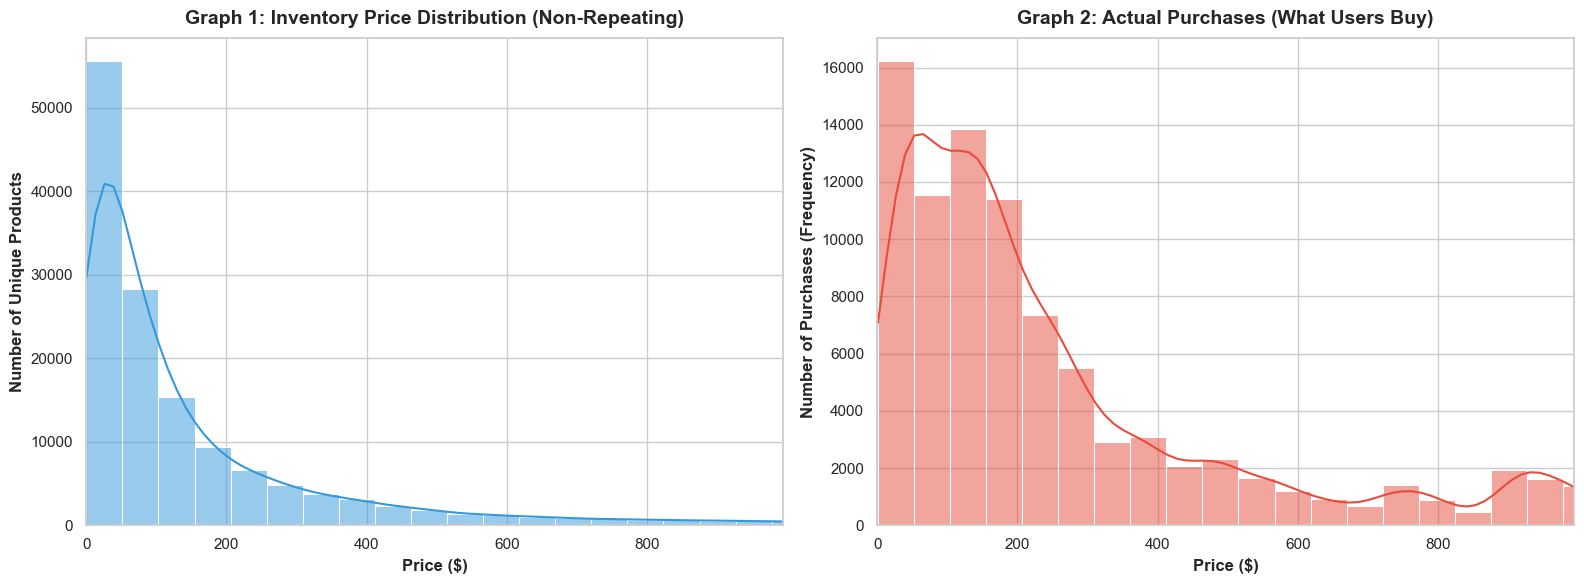

Graphs Plotted Successfully! 📊


In [ ]:
print("Generating Supply vs Demand Price Distributions...")
# MAGIC STEP: Extreme mehenge products se graph compress na ho, isliye limit lagana (95th Percentile)
price_limit = final_df['price'].quantile(0.95)

# STEP 1: Non-Repeating Data (Unique Products - Website ki Inventory)
# Hum har product_id ko sirf ek baar rakh rahe hain
unique_products_df = final_df.drop_duplicates(subset=['product_id'])

# STEP 2: Actual Purchases (Repeating - Log kya khareed rahe hain)
# Sirf un events ko filter kar rahe hain jahan logo ne actually purchase kiya
purchases_df = final_df[final_df['event_type'] == 'purchase']

# Subplots Setup (1 row, 2 columns)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRAPH 1: CATALOG/INVENTORY PRICING ---
sns.histplot(data=unique_products_df, x='price', bins=50, kde=True, color='#3498db', ax=axes[0])
axes[0].set_title('Graph 1: Inventory Price Distribution (Non-Repeating)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Price ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Unique Products', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, price_limit) # X-axis ko limit kiya

# --- GRAPH 2: PURCHASE PRICING ---
sns.histplot(data=purchases_df, x='price', bins=50, kde=True, color='#e74c3c', ax=axes[1])
axes[1].set_title('Graph 2: Actual Purchases (What Users Buy)', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Price ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Purchases (Frequency)', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, price_limit) # Same limit taaki comparison aasan ho

plt.tight_layout()
plt.show()
print("Graphs Plotted Successfully! ")

In [13]:
import pandas as pd
import numpy as np

print("🔍 PROVING THE HYPOTHESIS: Intra-Session Price Jumps...")

# STEP 1: Har session ka Min, Max, aur Average price nikalte hain
price_variance_df = final_df.groupby('user_session').agg(
    items_interacted=('price', 'count'),
    min_price=('price', 'min'),
    max_price=('price', 'max'),
    avg_price=('price', 'mean')
)

# STEP 2: Sirf un sessions ko rakhte hain jisme 1 se zyada items dekhe gaye
# (Kyunki jisne 1 hi item dekha, uska min aur max same hoga)
valid_sessions = price_variance_df[price_variance_df['items_interacted'] > 1].copy()

# STEP 3: Price ka "Jump" (Difference) calculate karna
valid_sessions['price_difference'] = valid_sessions['max_price'] - valid_sessions['min_price']

# STEP 4: Asli Proof (Numbers nikalna)
total_valid_sessions = len(valid_sessions)
jump_over_50 = len(valid_sessions[valid_sessions['price_difference'] > 50])
jump_over_200 = len(valid_sessions[valid_sessions['price_difference'] > 200])
jump_over_500 = len(valid_sessions[valid_sessions['price_difference'] > 500])

print("-" * 50)
print(f"Total Sessions analyzed (with >1 interactions): {total_valid_sessions:,}")
print("-" * 50)
print(f"⚠️ Sessions with > $50 price jump:  {jump_over_50:,} ({jump_over_50/total_valid_sessions*100:.2f}%)")
print(f"🚨 Sessions with > $200 price jump: {jump_over_200:,} ({jump_over_200/total_valid_sessions*100:.2f}%)")
print(f"🔥 Sessions with > $500 price jump: {jump_over_500:,} ({jump_over_500/total_valid_sessions*100:.2f}%)")
print("-" * 50)

# STEP 5: Un extreme cases ko dekhna jahan Average ne sabse bada dhoka diya!
print("\n👀 EXTREME EXAMPLES (Jahan Average Price puri tarah deceiving hai):")
# Hum wo top 5 rows dikhayenge jahan price difference sabse zyada hai
extreme_examples = valid_sessions.sort_values(by='price_difference', ascending=False)
display(extreme_examples.head(10))

🔍 PROVING THE HYPOTHESIS: Intra-Session Price Jumps...
--------------------------------------------------
Total Sessions analyzed (with >1 interactions): 877,283
--------------------------------------------------
⚠️ Sessions with > $50 price jump:  479,180 (54.62%)
🚨 Sessions with > $200 price jump: 272,542 (31.07%)
🔥 Sessions with > $500 price jump: 132,767 (15.13%)
--------------------------------------------------

👀 EXTREME EXAMPLES (Jahan Average Price puri tarah deceiving hai):


,items_interacted,min_price,max_price,avg_price,price_difference
user_session,,,,,
4686213e-ba9f-4ea8-8244-cdafa4c2bd89,132,0.0,2574.07,218.733712,2574.07
5e8b4ff1-e3d1-4098-b35c-d1b2d431a509,10,0.0,2574.07,936.962000,2574.07
3a9e0151-869a-4ae7-a2e9-b837adc82657,31,0.0,2574.07,478.397742,2574.07
27e31c40-5e6a-4179-8205-a109d6eb2391,13,0.0,2574.07,356.410000,2574.07
b8f36394-160e-4ed7-9ccc-29bf746fec00,17,0.0,2574.07,1293.667059,2574.07
f286335c-b2e6-4886-a7d6-2cbeb29e0b9c,48,0.0,2574.07,1500.161875,2574.07
7cecff7d-7488-4dd0-9690-1ad4a5fc3320,22,0.0,2574.07,566.562727,2574.07
a240a1bd-e505-4140-a308-677c324ba5b2,6,0.0,2574.07,1222.683333,2574.07
52c3fdda-815e-4aa5-a724-0e544e358f6a,6,0.0,2574.07,1561.601667,2574.07


In [12]:
extreme_examples.shape

(5, 5)

In [8]:
valid_sessions.head(4)

,items_interacted,min_price,max_price,avg_price,price_difference
user_session,,,,,
000009c4-a1dd-4764-87d9-24f3d7e43c4f,9,458.25,1329.44,822.974444,871.19
000029a6-1986-4a71-8139-53669c1adaba,6,297.49,427.78,362.676667,130.29
00003dca-5a5a-4af2-86ef-9851ceb02a2b,2,127.15,127.15,127.150000,0.00
00004022-c43d-4223-b5ad-da2b0e59b84f,10,144.12,1994.65,674.301000,1850.53


C:\Users\asus\AppData\Local\Temp\ipykernel_5892\2362239005.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_viewed.values, y=top_viewed.index, ax=axes[0], palette='Blues_r')
C:\Users\asus\AppData\Local\Temp\ipykernel_5892\2362239005.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_purchased.values, y=top_purchased.index, ax=axes[1], palette='Greens_r')


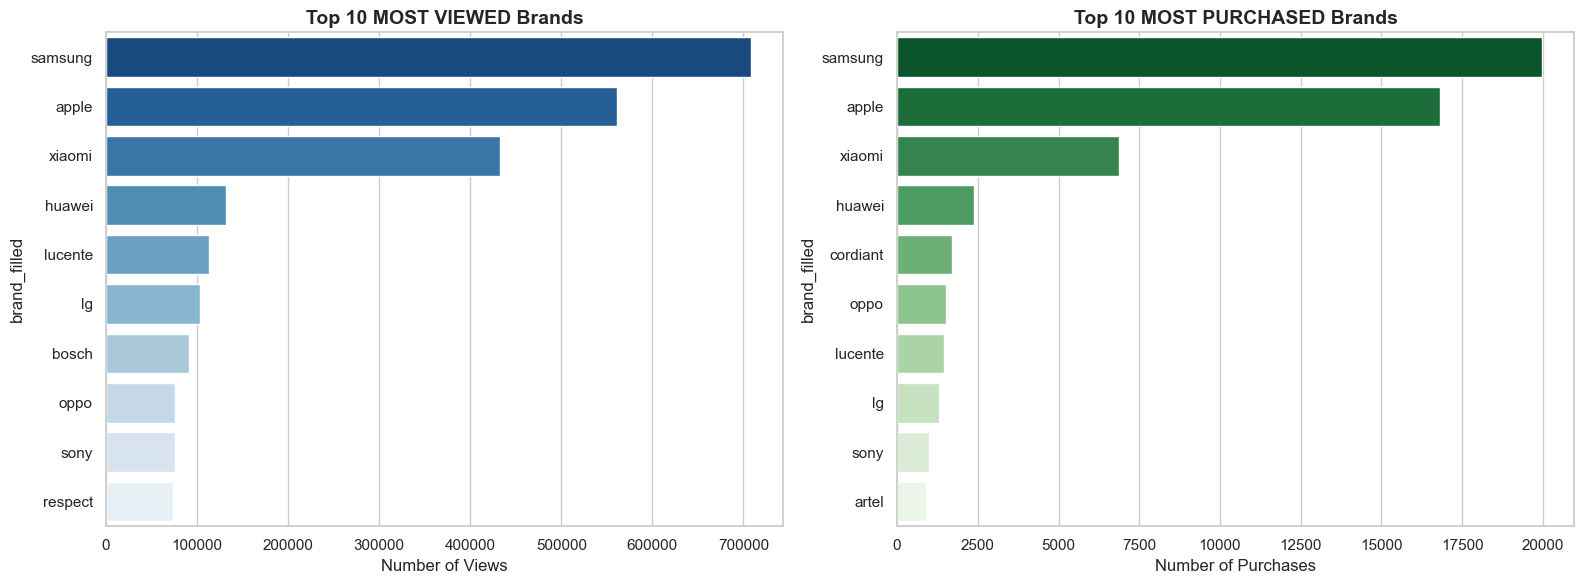

In [6]:
# 'unbranded' ko filter kar rahe hain actual brand insights ke liye
branded_df = final_df[final_df['brand_filled'] != 'unbranded']

# Top 10 Viewed Brands
top_viewed = branded_df[branded_df['event_type'] == 'view']['brand_filled'].value_counts().head(10)

# Top 10 Purchased Brands
top_purchased = branded_df[branded_df['event_type'] == 'purchase']['brand_filled'].value_counts().head(10)

# 2 subplots banayenge aamne-saamne compare karne ke liye
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Graph: Views
sns.barplot(x=top_viewed.values, y=top_viewed.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 MOST VIEWED Brands', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Views')

# Right Graph: Purchases
sns.barplot(x=top_purchased.values, y=top_purchased.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 MOST PURCHASED Brands', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Purchases')

plt.tight_layout()
plt.show()

# Actual Buyer Analysis:-

In [15]:
final_df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
5,2019-11-01 19:11:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
6,2019-11-01 19:12:49+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
7,2019-11-01 19:13:17+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
8,2019-11-01 19:14:07+00:00,view,5100855,2053013553341792533,electronics.clocks,apple,548.02,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.clocks,apple,19
9,2019-11-01 19:14:58+00:00,view,1005073,2053013555631882655,electronics.smartphone,samsung,1133.09,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19


In [16]:
(final_df['price']==0).sum()

np.int64(18646)

In [17]:
((final_df['price']==0).sum()/final_df.shape[0])*100

np.float64(0.27716292545274573)

In [9]:
final_df[final_df['price']==0].head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
2617,2019-11-16 08:16:27+00:00,view,100011061,2053013558249128509,NaN,NaN,0.0,513872882,0019ca0c-abca-4c4c-b157-a34744db3d38,NaN,nicecooker,8
2618,2019-11-16 08:17:13+00:00,view,100011061,2053013558249128509,NaN,NaN,0.0,513872882,0019ca0c-abca-4c4c-b157-a34744db3d38,NaN,nicecooker,8
2619,2019-11-16 08:19:02+00:00,view,100011061,2053013558249128509,NaN,NaN,0.0,513872882,0019ca0c-abca-4c4c-b157-a34744db3d38,NaN,nicecooker,8
2620,2019-11-16 08:19:16+00:00,view,100011061,2053013558249128509,NaN,NaN,0.0,513872882,0019ca0c-abca-4c4c-b157-a34744db3d38,NaN,nicecooker,8
2621,2019-11-16 08:20:31+00:00,view,100011061,2053013558249128509,NaN,NaN,0.0,513872882,0019ca0c-abca-4c4c-b157-a34744db3d38,NaN,nicecooker,8
2622,2019-11-16 08:21:29+00:00,view,100011061,2053013558249128509,NaN,NaN,0.0,513872882,0019ca0c-abca-4c4c-b157-a34744db3d38,NaN,nicecooker,8
3178,2019-11-15 09:52:52+00:00,view,100010505,2179887855134835524,NaN,NaN,0.0,530517434,001e865a-3d5c-4dad-a783-1f6412a3e213,NaN,omabelle,9
3290,2019-11-15 08:53:28+00:00,view,100010496,2179887855134835524,NaN,NaN,0.0,541738566,001f9de7-6a82-47c5-86bb-fc40afa355cb,NaN,omabelle,8
3292,2019-11-15 08:53:59+00:00,view,100010496,2179887855134835524,NaN,NaN,0.0,541738566,001f9de7-6a82-47c5-86bb-fc40afa355cb,NaN,omabelle,8
3346,2019-11-14 17:48:51+00:00,view,100006963,2053013554415534427,electronics.video.tv,NaN,0.0,550467736,002093f2-dd97-4b25-bf0a-d241c4e8c58d,electronics.video.tv,yasin,17


In [ ]:
final_df

### Removing the 0 price columns

In [18]:
# Sirf wo rows rakhein jinki price 0 se zyada hai
final_df = final_df[final_df['price'] > 0]

# Verify karein
print(f"Rows after removing zero prices: {final_df.shape[0]}")

Rows after removing zero prices: 6708805


### total_unique_Sessions:-

In [20]:
final_df['user_session'].nunique()

1376620

In [19]:

# 1. Pehle wo sessions identify karein jisme 'purchase' event hua hai
purchase_session_ids = final_df[final_df['event_type'] == 'purchase']['user_session'].unique()

# 2. Sirf un sessions ka data filter karein
buying_sessions_data = final_df[final_df['user_session'].isin(purchase_session_ids)]

# 3. Har session ke liye Price Statistics calculate karein
session_variance = buying_sessions_data.groupby('user_session')['price'].agg(
    min_price='min',
    max_price='max',
    avg_price='mean',
    price_std_dev='std', # Statistical variance check karne ke liye
    total_items_interacted='count'
).reset_index()

# 4. Price Range (Max - Min) calculate karein
session_variance['price_range'] = session_variance['max_price'] - session_variance['min_price']

# 5. Ratio nikaalein (High range vs Low range)
# Agar range > $500 hai, toh iska matlab user ne extreme variety dekhi hai
session_variance['is_high_variance'] = session_variance['price_range'] > 500

# Results Summary
print(f"Total Purchasing Sessions: {len(session_variance)}")
print(f"Sessions with Price Range > $500: {session_variance['is_high_variance'].sum()}")
print("\nTop 10 High Variance Sessions (Example):")
display(session_variance.sort_values(by='price_range', ascending=False).head(10))

Total Purchasing Sessions: 77447
Sessions with Price Range > $500: 6086

Top 10 High Variance Sessions (Example):


,user_session,min_price,max_price,avg_price,price_std_dev,total_items_interacted,price_range,is_high_variance
46781,9a1e9f9e-b10b-4b38-ac71-42e1a6091c90,3.69,2574.07,107.657368,415.762834,38,2570.38,True
5122,108923ee-4fcd-4b71-b600-3679ceb46c37,4.25,2574.07,137.376154,497.325829,26,2569.82,True
12690,2a3327b6-729c-4e8f-af6c-c94d94aa1608,2.01,2571.24,398.246441,706.191558,59,2569.23,True
43242,8e584a39-05e6-4723-ae27-8e859359be71,7.31,2574.07,544.057500,825.400130,44,2566.76,True
72596,eff05c61-f10c-44bb-92ce-8ab5da4027fa,7.36,2574.07,770.675833,751.223988,12,2566.71,True
45895,9749f118-d19a-4e0b-b60d-6c91bde7e7aa,8.37,2574.07,278.080000,641.343492,15,2565.70,True
65649,d9058bf1-797f-4431-93bb-74337870886a,6.95,2572.23,149.899500,347.410548,60,2565.28,True
9790,2051a8db-bf9b-4686-a343-6001b564302a,7.71,2572.23,648.840000,1282.260000,4,2564.52,True
68956,e3db2a58-8d43-4937-92c5-a75a2d10171c,11.81,2573.79,454.279625,632.395844,80,2561.98,True
18161,3c204630-ad6d-4e6a-9566-f6676e8f6528,2.43,2562.49,626.146364,949.092934,11,2560.06,True


Generating 'Consideration Set vs Actual Purchase' Analysis...
-----------------------------------------------------------------
Total Buyers who compared multiple items: 39,795
🔼 Up-Sold (Bought > $50 than their average): 6,114 (15.4%)
🔽 Deal Hunters (Bought < $50 than their average): 7,252 (18.2%)
✅ Consistent Buyers (Bought near their average): 26,429 (66.4%)
-----------------------------------------------------------------


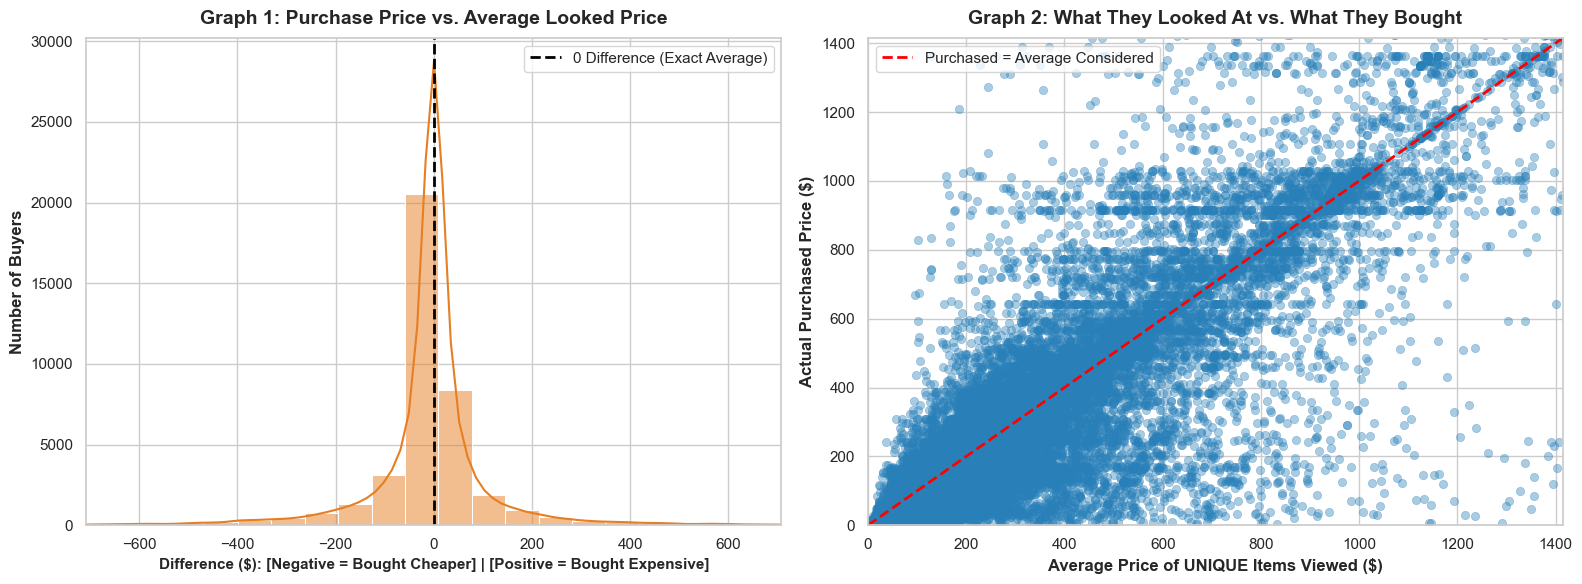

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating 'Consideration Set vs Actual Purchase' Analysis...")

# STEP 1: Sirf un sessions ko nikalna jahan purchase hui hai
purchased_sessions = final_df[final_df['event_type'] == 'purchase']['user_session'].unique()
buyer_events = final_df[final_df['user_session'].isin(purchased_sessions)]

# STEP 2: Actual Purchase Price nikalna
# (Agar kisi ne cart mein 2 cheezein khareedi hain, toh hum unka average purchase price le lenge)
purchase_data = buyer_events[buyer_events['event_type'] == 'purchase']
actual_purchase_price = purchase_data.groupby('user_session')['price'].mean().rename('purchased_price')

# STEP 3: "Consideration Set" banانا (Sirf UNIQUE products jo dekhe gaye)
# 'drop_duplicates' se ek product ko ek hi baar gina jayega, chahe 10 baar view kiya ho
consideration_set = buyer_events.drop_duplicates(subset=['user_session', 'product_id'])

# STEP 4: Consideration set ke statistics nikalna
consideration_stats = consideration_set.groupby('user_session').agg(
    unique_products_seen=('product_id', 'nunique'),
    min_considered_price=('price', 'min'),
    max_considered_price=('price', 'max'),
    avg_considered_price=('price', 'mean')
)

# STEP 5: Dono tables ko jodna (Merge)
analysis_df = consideration_stats.join(actual_purchase_price, how='inner')

# STEP 6: Filter - Sirf unhe rakhna jinhone 1 se zyada UNIQUE item dekhe
# (Jisne 1 hi dekha aur wahi khareed liya, uska comparison nahi ho sakta)
valid_buyers = analysis_df[analysis_df['unique_products_seen'] > 1].copy()

# STEP 7: The Magic Metric (Purchase Price - Average Considered Price)
# Agar positive aaya -> User ne apni average soch se mehenga khareeda (Upsell)
# Agar negative aaya -> User ne sasta khareeda (Deal hunter)
valid_buyers['purchase_vs_avg_diff'] = valid_buyers['purchased_price'] - valid_buyers['avg_considered_price']


# ---- PRINTING INSIGHTS ----
total_analyzed = len(valid_buyers)
bought_expensive = len(valid_buyers[valid_buyers['purchase_vs_avg_diff'] > 50])
bought_cheap = len(valid_buyers[valid_buyers['purchase_vs_avg_diff'] < -50])
bought_consistent = total_analyzed - (bought_expensive + bought_cheap)

print("-" * 65)
print(f"Total Buyers who compared multiple items: {total_analyzed:,}")
print(f"🔼 Up-Sold (Bought > $50 than their average): {bought_expensive:,} ({bought_expensive/total_analyzed*100:.1f}%)")
print(f"🔽 Deal Hunters (Bought < $50 than their average): {bought_cheap:,} ({bought_cheap/total_analyzed*100:.1f}%)")
print(f"✅ Consistent Buyers (Bought near their average): {bought_consistent:,} ({bought_consistent/total_analyzed*100:.1f}%)")
print("-" * 65)


# STEP 8: VISUALIZATION (2 GRAPHS)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

limit_price = valid_buyers['max_considered_price'].quantile(0.95)

# --- GRAPH 1: The Difference Distribution ---
sns.histplot(data=valid_buyers, x='purchase_vs_avg_diff', bins=50, kde=True, color='#e67e22', ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', linewidth=2, label='0 Difference (Exact Average)')
axes[0].set_title('Graph 1: Purchase Price vs. Average Looked Price', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Difference ($): [Negative = Bought Cheaper] | [Positive = Bought Expensive]', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Buyers', fontsize=12, fontweight='bold')
axes[0].set_xlim(-limit_price/2, limit_price/2)
axes[0].legend()

# --- GRAPH 2: Scatter (Average Considered vs Actual Purchase) ---
sns.scatterplot(data=valid_buyers, x='avg_considered_price', y='purchased_price', alpha=0.4, color='#2980b9', edgecolor=None, ax=axes[1])
axes[1].plot([0, limit_price], [0, limit_price], color='red', linestyle='--', linewidth=2, label='Purchased = Average Considered')

axes[1].set_title('Graph 2: What They Looked At vs. What They Bought', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Average Price of UNIQUE Items Viewed ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Purchased Price ($)', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, limit_price)
axes[1].set_ylim(0, limit_price)
axes[1].legend()

plt.tight_layout()
plt.show()

## Considering_variance_in_purchasing:-

Generating 'Consideration Set vs Actual Purchase' Analysis (Using Max & Median)...
-----------------------------------------------------------------
Total Buyers who compared multiple items: 39,795
🔼 Up-Sold (Bought > $50 than their median): 8,407 (21.1%)
🔽 Deal Hunters (Bought < $50 than their median): 4,347 (10.9%)
✅ Consistent Buyers (Bought near their median): 27,041 (68.0%)
-----------------------------------------------------------------


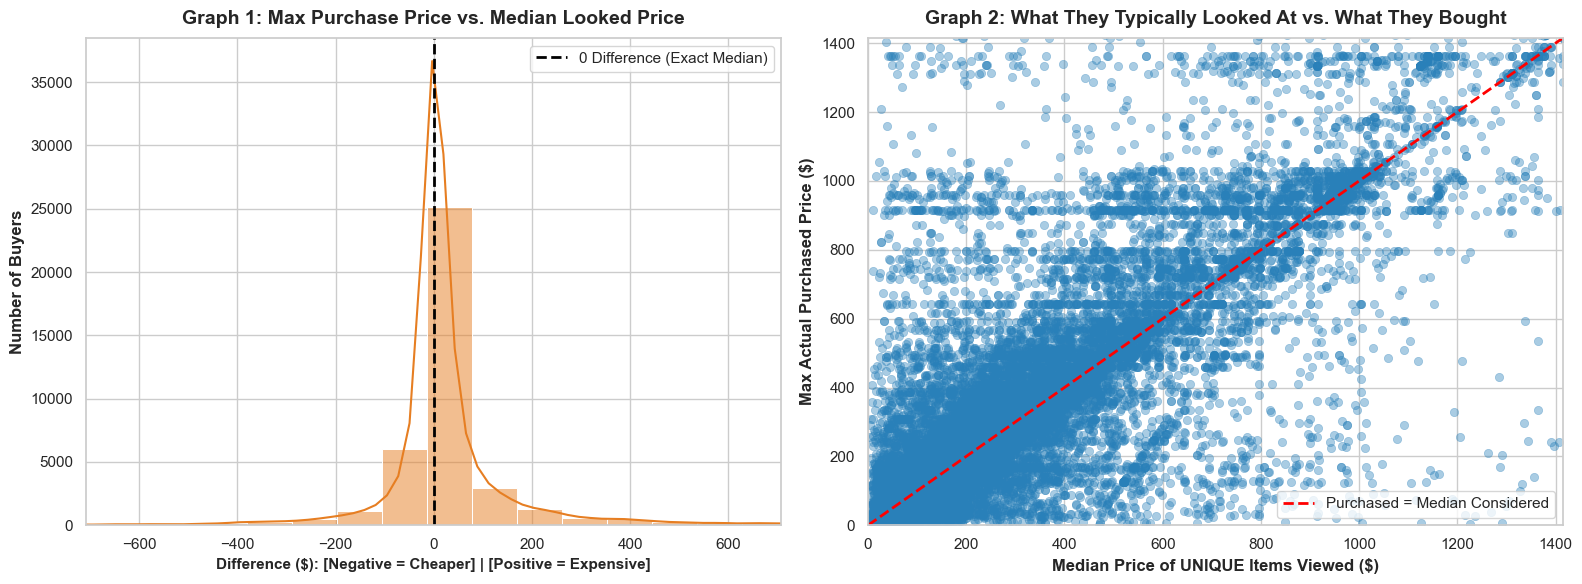

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating 'Consideration Set vs Actual Purchase' Analysis (Using Max & Median)...")

# STEP 1: Sirf un sessions ko nikalna jahan purchase hui hai
purchased_sessions = final_df[final_df['event_type'] == 'purchase']['user_session'].unique()
buyer_events = final_df[final_df['user_session'].isin(purchased_sessions)]

# STEP 2: Actual Purchase Price nikalna (FIXED: Using MAX instead of MEAN)
# Taki bundles/cheap accessories ki wajah se main purchase price dilute na ho
purchase_data = buyer_events[buyer_events['event_type'] == 'purchase']
actual_purchase_price = purchase_data.groupby('user_session')['price'].max().rename('purchased_price')

# STEP 3: "Consideration Set" banana (Sirf UNIQUE products jo dekhe gaye)
# 'drop_duplicates' se ek product ko ek hi baar gina jayega
consideration_set = buyer_events.drop_duplicates(subset=['user_session', 'product_id'])

# STEP 4: Consideration set ke statistics nikalna (FIXED: Using MEDIAN instead of MEAN)
# Median extreme high/low prices (outliers) se affect nahi hota
consideration_stats = consideration_set.groupby('user_session').agg(
    unique_products_seen=('product_id', 'nunique'),
    min_considered_price=('price', 'min'),
    max_considered_price=('price', 'max'),
    median_considered_price=('price', 'median')
)

# STEP 5: Dono tables ko jodna (Merge)
analysis_df = consideration_stats.join(actual_purchase_price, how='inner')

# STEP 6: Filter - Sirf unhe rakhna jinhone 1 se zyada UNIQUE item dekhe
valid_buyers = analysis_df[analysis_df['unique_products_seen'] > 1].copy()

# STEP 7: The Magic Metric (Max Purchase Price - Median Considered Price)
# Agar positive aaya -> User ne apni typical soch (median) se mehenga khareeda (Upsell)
# Agar negative aaya -> User ne sasta khareeda (Deal hunter)
valid_buyers['purchase_vs_median_diff'] = valid_buyers['purchased_price'] - valid_buyers['median_considered_price']


# ---- PRINTING INSIGHTS ----
total_analyzed = len(valid_buyers)
bought_expensive = len(valid_buyers[valid_buyers['purchase_vs_median_diff'] > 50])
bought_cheap = len(valid_buyers[valid_buyers['purchase_vs_median_diff'] < -50])
bought_consistent = total_analyzed - (bought_expensive + bought_cheap)

print("-" * 65)
print(f"Total Buyers who compared multiple items: {total_analyzed:,}")
print(f"🔼 Up-Sold (Bought > $50 than their median): {bought_expensive:,} ({bought_expensive/total_analyzed*100:.1f}%)")
print(f"🔽 Deal Hunters (Bought < $50 than their median): {bought_cheap:,} ({bought_cheap/total_analyzed*100:.1f}%)")
print(f"✅ Consistent Buyers (Bought near their median): {bought_consistent:,} ({bought_consistent/total_analyzed*100:.1f}%)")
print("-" * 65)


# STEP 8: VISUALIZATION (2 GRAPHS)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

limit_price = valid_buyers['max_considered_price'].quantile(0.95)

# --- GRAPH 1: The Difference Distribution ---
sns.histplot(data=valid_buyers, x='purchase_vs_median_diff', bins=50, kde=True, color='#e67e22', ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', linewidth=2, label='0 Difference (Exact Median)')
axes[0].set_title('Graph 1: Max Purchase Price vs. Median Looked Price', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Difference ($): [Negative = Cheaper] | [Positive = Expensive]', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Buyers', fontsize=12, fontweight='bold')
axes[0].set_xlim(-limit_price/2, limit_price/2)
axes[0].legend()

# --- GRAPH 2: Scatter (Median Considered vs Actual Purchase) ---
sns.scatterplot(data=valid_buyers, x='median_considered_price', y='purchased_price', alpha=0.4, color='#2980b9', edgecolor=None, ax=axes[1])
axes[1].plot([0, limit_price], [0, limit_price], color='red', linestyle='--', linewidth=2, label='Purchased = Median Considered')

axes[1].set_title('Graph 2: What They Typically Looked At vs. What They Bought', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Median Price of UNIQUE Items Viewed ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Max Actual Purchased Price ($)', fontsize=12, fontweight='bold')
axes[1].set_xlim(0, limit_price)
axes[1].set_ylim(0, limit_price)
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
valid_buyers

,unique_products_seen,min_considered_price,max_considered_price,avg_considered_price,purchased_price,purchase_vs_avg_diff
user_session,,,,,,
0004a582-9137-4a9b-9695-b743eaea850f,2,167.06,913.28,540.170000,167.06,-373.110000
0005f025-d675-4344-897c-68897a6ea601,2,139.13,360.92,250.025000,360.92,110.895000
000712b3-ca94-421f-b126-fbff68dc4776,5,4.79,488.82,222.904000,15.42,-207.484000
00077187-2140-4a0e-a806-3d20b8d533dc,12,175.01,333.83,241.213333,256.33,15.116667
000990d8-3962-4e52-9c88-8c011e888126,3,6.67,218.51,113.490000,218.51,105.020000
...,...,...,...,...,...,...
fff97709-16ab-4c09-b1b8-77ed83806fe4,3,93.95,124.70,107.633333,104.25,-3.383333
fff9a04e-21c2-444b-8e59-4b0849a69e88,6,90.61,120.47,100.590000,120.47,19.880000
fffd2805-0b1f-47d8-ab9e-ff94bd81fe6c,4,135.26,199.66,173.770000,164.85,-8.920000


Whichpricecan be taken as ameasure??

In [23]:
buyer_events.head(10)#Ye wo session h jisme purchase hui h 

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
66,2019-11-03 15:03:45+00:00,view,26300735,2053013563584283495,NaN,NaN,153.67,512454459,000199a3-437c-4ae8-b26b-01e0f34c1418,NaN,NaN,15
67,2019-11-03 15:06:34+00:00,purchase,26300735,2053013563584283495,NaN,NaN,153.67,512454459,000199a3-437c-4ae8-b26b-01e0f34c1418,NaN,NaN,15
68,2019-11-03 15:07:07+00:00,view,26300735,2053013563584283495,NaN,NaN,153.67,512454459,000199a3-437c-4ae8-b26b-01e0f34c1418,NaN,NaN,15
72,2019-11-22 04:24:42+00:00,view,1004767,2053013555631882655,electronics.smartphone,samsung,246.00,574429172,0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c,electronics.smartphone,samsung,4
73,2019-11-22 04:25:19+00:00,cart,1004767,2053013555631882655,electronics.smartphone,samsung,246.00,574429172,0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c,electronics.smartphone,samsung,4
74,2019-11-22 04:27:03+00:00,purchase,1004767,2053013555631882655,electronics.smartphone,samsung,246.00,574429172,0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c,electronics.smartphone,samsung,4
75,2019-11-22 04:27:34+00:00,view,1004767,2053013555631882655,electronics.smartphone,samsung,246.00,574429172,0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c,electronics.smartphone,samsung,4
76,2019-11-22 04:27:57+00:00,cart,1004767,2053013555631882655,electronics.smartphone,samsung,246.00,574429172,0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c,electronics.smartphone,samsung,4
77,2019-11-22 04:29:15+00:00,purchase,1004767,2053013555631882655,electronics.smartphone,samsung,246.00,574429172,0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c,electronics.smartphone,samsung,4
78,2019-11-22 04:30:05+00:00,view,1004767,2053013555631882655,electronics.smartphone,samsung,246.00,574429172,0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c,electronics.smartphone,samsung,4


In [ ]:
actual_purchase_price#We are considering the max buying done by the customer:-

user_session
000199a3-437c-4ae8-b26b-01e0f34c1418    153.67
0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c    246.00
0002e288-569b-4642-8a82-b183ee537259    211.02
00035f1a-f4f4-4170-8207-6406ec0259d7     89.81
00048083-ce0e-4462-b6c5-1b61dcbe43a1    128.42
                                         ...  
fffd2805-0b1f-47d8-ab9e-ff94bd81fe6c    164.85
fffd9089-fafe-4195-82de-e668ade4967e     20.05
ffff31c8-cbb6-4f1f-aa6f-5584df4dea04    238.67
ffff88ea-d671-43b6-9c0a-7dc3614dc229    959.73
ffffb94a-cea4-429d-ba4a-7e47a6f28171    977.86
Name: purchased_price, Length: 77447, dtype: float64

In [27]:
print("🧪 RUNNING MEGA BUDGET ESTIMATOR ANALYSIS (5 Contenders)...")

# STEP 1: Time ke hisaab se sort karna (Taaki hum 'Last Viewed' nikal sakein)
buyer_events_sorted = buyer_events.sort_values(by=['user_session', 'event_time'])

# STEP 2: Sirf 'views' ko filter karna (Kyunki hum budget 'sochne' ki process measure kar rahe hain)
views_only = buyer_events_sorted[buyer_events_sorted['event_type'] == 'view']

# STEP 3: Har user session ka Mean, Median, Last Viewed, aur Percentiles nikalna
# NAYA: Humne 75th aur 25th Percentile add kiya hai lambda function use karke
budget_estimators = views_only.groupby('user_session').agg(
    mean_budget=('price', 'mean'),
    median_budget=('price', 'median'),
    last_viewed_price=('price', 'last'), 
    p75_budget=('price', lambda x: x.quantile(0.75)), # 75th Percentile (Premium choice)
    p25_budget=('price', lambda x: x.quantile(0.25))  # 25th Percentile (Budget choice)
)

# STEP 4: Asli Purchase Price ke sath Join karna
budget_test_df = budget_estimators.join(actual_purchase_price, how='inner')

# STEP 5: ERROR CALCULATE KARNA (Kiska Andaza Sabse Sahi Tha?)
budget_test_df['error_mean'] = abs(budget_test_df['mean_budget'] - budget_test_df['purchased_price'])
budget_test_df['error_median'] = abs(budget_test_df['median_budget'] - budget_test_df['purchased_price'])
budget_test_df['error_last_view'] = abs(budget_test_df['last_viewed_price'] - budget_test_df['purchased_price'])
budget_test_df['error_p75'] = abs(budget_test_df['p75_budget'] - budget_test_df['purchased_price'])
budget_test_df['error_p25'] = abs(budget_test_df['p25_budget'] - budget_test_df['purchased_price'])

# STEP 6: Asli Proof (Mean Absolute Error - Har metric average kitne dollar se chook gaya)
mae_mean = budget_test_df['error_mean'].mean()
mae_median = budget_test_df['error_median'].mean()
mae_last_view = budget_test_df['error_last_view'].mean()
mae_p75 = budget_test_df['error_p75'].mean()
mae_p25 = budget_test_df['error_p25'].mean()

print("\n" + "="*55)
print("📊 THE MEGA BUDGET METRIC TOURNAMENT")
print("="*55)
print(f"1. Average (Mean) Error : Off by ${mae_mean:.2f} on average")
print(f"2. Median Error         : Off by ${mae_median:.2f} on average")
print(f"3. Last Viewed Error    : Off by ${mae_last_view:.2f} on average")
print(f"4. 75th Percentile Error: Off by ${mae_p75:.2f} on average")
print(f"5. 25th Percentile Error: Off by ${mae_p25:.2f} on average")
print("="*55)

# WINNER DECLARATION LOGIC
errors = {
    "MEAN (Average)": mae_mean,
    "MEDIAN (50th Percentile)": mae_median,
    "LAST VIEWED PRICE": mae_last_view,
    "75th PERCENTILE": mae_p75,
    "25th PERCENTILE": mae_p25
}

# Sabse kam error nikalna aur winner print karna
best_metric_name = min(errors, key=errors.get)
best_metric_value = errors[best_metric_name]

print(f"🏆 ULTIMATE WINNER: {best_metric_name} with the lowest error of ${best_metric_value:.2f}!")

🧪 RUNNING MEGA BUDGET ESTIMATOR ANALYSIS (5 Contenders)...



📊 THE MEGA BUDGET METRIC TOURNAMENT
1. Average (Mean) Error : Off by $36.40 on average
2. Median Error         : Off by $28.03 on average
3. Last Viewed Error    : Off by $33.23 on average
4. 75th Percentile Error: Off by $29.26 on average
5. 25th Percentile Error: Off by $39.36 on average
🏆 ULTIMATE WINNER: MEDIAN (50th Percentile) with the lowest error of $28.03!


In [28]:
import pandas as pd
import numpy as np
import time

print("⚡ RUNNING OPTIMIZED MEGA BUDGET ESTIMATOR (Lightning Fast)...")
start_time = time.time()

# STEP 1 & 2: Sort and Filter
buyer_events_sorted = buyer_events.sort_values(by=['user_session', 'event_time'])
views_only = buyer_events_sorted[buyer_events_sorted['event_type'] == 'view']

# STEP 3: Fast Groupby without lambda (Vectorized C-level execution)
# 1. Basic metrics ek sath nikalna
basic_metrics = views_only.groupby('user_session').agg(
    mean_budget=('price', 'mean'),
    median_budget=('price', 'median'),
    last_viewed_price=('price', 'last')
)

# 2. Quantiles alag se nikalna (Yeh inherently fast hota hai bina lambda ke)
grouped_views = views_only.groupby('user_session')['price']
p75_budget = grouped_views.quantile(0.75).rename('p75_budget')
p25_budget = grouped_views.quantile(0.25).rename('p25_budget')

# 3. Sabko ek saath combine (concat) karna
budget_estimators = pd.concat([basic_metrics, p75_budget, p25_budget], axis=1)

# STEP 4: Asli Purchase Price ke sath Join karna
budget_test_df = budget_estimators.join(actual_purchase_price, how='inner')

# STEP 5: ERROR CALCULATE KARNA
budget_test_df['error_mean'] = abs(budget_test_df['mean_budget'] - budget_test_df['purchased_price'])
budget_test_df['error_median'] = abs(budget_test_df['median_budget'] - budget_test_df['purchased_price'])
budget_test_df['error_last_view'] = abs(budget_test_df['last_viewed_price'] - budget_test_df['purchased_price'])
budget_test_df['error_p75'] = abs(budget_test_df['p75_budget'] - budget_test_df['purchased_price'])
budget_test_df['error_p25'] = abs(budget_test_df['p25_budget'] - budget_test_df['purchased_price'])

# STEP 6: Asli Proof (Mean Absolute Error)
errors = {
    "MEAN (Average)": budget_test_df['error_mean'].mean(),
    "MEDIAN (50th Percentile)": budget_test_df['error_median'].mean(),
    "LAST VIEWED PRICE": budget_test_df['error_last_view'].mean(),
    "75th PERCENTILE": budget_test_df['error_p75'].mean(),
    "25th PERCENTILE": budget_test_df['error_p25'].mean()
}

print("\n" + "="*55)
print("📊 THE MEGA BUDGET METRIC TOURNAMENT")
print("="*55)
for name, error_val in errors.items():
    print(f"-> {name:25} : Off by ${error_val:.2f} on average")
print("="*55)

# WINNER DECLARATION
best_metric_name = min(errors, key=errors.get)
best_metric_value = errors[best_metric_name]

print(f"🏆 ULTIMATE WINNER: {best_metric_name} with the lowest error of ${best_metric_value:.2f}!")
print(f"⏱️ Code Executed in: {(time.time() - start_time):.2f} seconds")

⚡ RUNNING OPTIMIZED MEGA BUDGET ESTIMATOR (Lightning Fast)...

📊 THE MEGA BUDGET METRIC TOURNAMENT
-> MEAN (Average)            : Off by $36.40 on average
-> MEDIAN (50th Percentile)  : Off by $28.03 on average
-> LAST VIEWED PRICE         : Off by $33.23 on average
-> 75th PERCENTILE           : Off by $29.26 on average
-> 25th PERCENTILE           : Off by $39.36 on average
🏆 ULTIMATE WINNER: MEDIAN (50th Percentile) with the lowest error of $28.03!
⏱️ Code Executed in: 3.84 seconds


In [29]:
budget_estimators

,mean_budget,median_budget,last_viewed_price,p75_budget,p25_budget
user_session,,,,,
000199a3-437c-4ae8-b26b-01e0f34c1418,153.670000,153.670,153.67,153.67,153.67
0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c,246.000000,246.000,246.00,246.00,246.00
0002e288-569b-4642-8a82-b183ee537259,211.020000,211.020,211.02,211.02,211.02
00035f1a-f4f4-4170-8207-6406ec0259d7,89.810000,89.810,89.81,89.81,89.81
00048083-ce0e-4462-b6c5-1b61dcbe43a1,128.420000,128.420,128.42,128.42,128.42
...,...,...,...,...,...
fffd2805-0b1f-47d8-ab9e-ff94bd81fe6c,171.986000,164.850,164.85,195.31,164.85
fffd9089-fafe-4195-82de-e668ade4967e,23.013750,20.050,20.05,20.05,20.05
ffff31c8-cbb6-4f1f-aa6f-5584df4dea04,238.670000,238.670,238.67,238.67,238.67


In [30]:
actual_purchase_price

user_session
000199a3-437c-4ae8-b26b-01e0f34c1418    153.67
0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c    246.00
0002e288-569b-4642-8a82-b183ee537259    211.02
00035f1a-f4f4-4170-8207-6406ec0259d7     89.81
00048083-ce0e-4462-b6c5-1b61dcbe43a1    128.42
                                         ...  
fffd2805-0b1f-47d8-ab9e-ff94bd81fe6c    164.85
fffd9089-fafe-4195-82de-e668ade4967e     20.05
ffff31c8-cbb6-4f1f-aa6f-5584df4dea04    238.67
ffff88ea-d671-43b6-9c0a-7dc3614dc229    959.73
ffffb94a-cea4-429d-ba4a-7e47a6f28171    977.86
Name: purchased_price, Length: 77447, dtype: float64

In [ ]:
budget_test_df = budget_estimators.join(actual_purchase_price, how='inner')


In [20]:
budget_test_df

,mean_budget,median_budget,last_viewed_price,purchased_price,error_mean,error_median,error_last_view
user_session,,,,,,,
000199a3-437c-4ae8-b26b-01e0f34c1418,153.670000,153.670,153.67,153.67,0.000000,0.000,0.0
0001a1b4-7adf-4c7a-9230-fdc1f1ae4e7c,246.000000,246.000,246.00,246.00,0.000000,0.000,0.0
0002e288-569b-4642-8a82-b183ee537259,211.020000,211.020,211.02,211.02,0.000000,0.000,0.0
00035f1a-f4f4-4170-8207-6406ec0259d7,89.810000,89.810,89.81,89.81,0.000000,0.000,0.0
00048083-ce0e-4462-b6c5-1b61dcbe43a1,128.420000,128.420,128.42,128.42,0.000000,0.000,0.0
...,...,...,...,...,...,...,...
fffd2805-0b1f-47d8-ab9e-ff94bd81fe6c,171.986000,164.850,164.85,164.85,7.136000,0.000,0.0
fffd9089-fafe-4195-82de-e668ade4967e,23.013750,20.050,20.05,20.05,2.963750,0.000,0.0
ffff31c8-cbb6-4f1f-aa6f-5584df4dea04,238.670000,238.670,238.67,238.67,0.000000,0.000,0.0


In [26]:
final_df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
5,2019-11-01 19:11:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
6,2019-11-01 19:12:49+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
7,2019-11-01 19:13:17+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
8,2019-11-01 19:14:07+00:00,view,5100855,2053013553341792533,electronics.clocks,apple,548.02,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.clocks,apple,19
9,2019-11-01 19:14:58+00:00,view,1005073,2053013555631882655,electronics.smartphone,samsung,1133.09,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19


🔍 VERIFYING THE 'PRICE vs CONVERSION' HYPOTHESIS...

📊 THE PRICE FUNNEL REALITY:


event_type,View_to_Cart_Rate (%),Cart_to_Purchase_Rate (%),Overall_Conversion (%)
price_bucket,,,
1. Budget (<$50),4.63,29.05,1.35
2. Economy ($50-$200),4.62,32.01,1.48
3. Mid-Range ($200-$500),4.66,31.17,1.45
4. Premium ($500-$1000),4.68,32.80,1.54
5. Luxury (>$1000),4.31,34.59,1.49


C:\Users\asus\AppData\Local\Temp\ipykernel_21396\3370263428.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=funnel_stats.index, y=funnel_stats['View_to_Cart_Rate (%)'], palette="Blues_d", ax=axes[0])
C:\Users\asus\AppData\Local\Temp\ipykernel_21396\3370263428.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=funnel_stats.index, y=funnel_stats['Cart_to_Purchase_Rate (%)'], palette="Oranges_d", ax=axes[1])


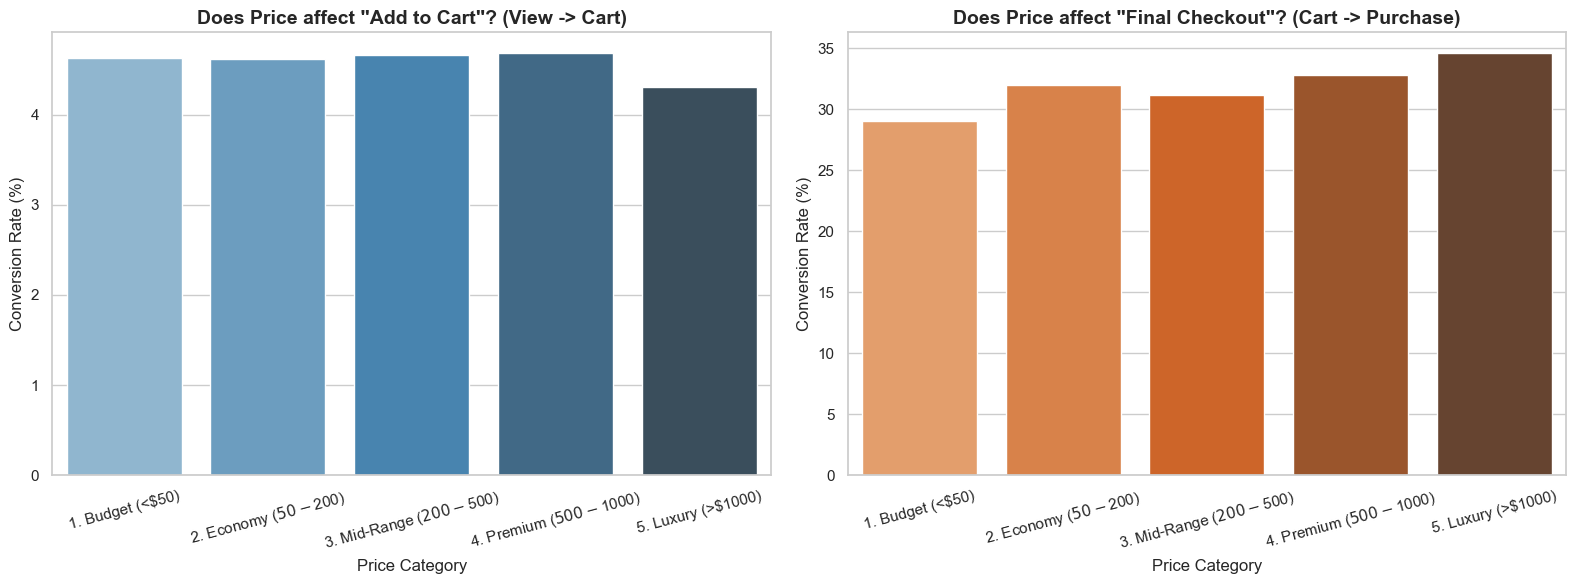

In [33]:
print("🔍 VERIFYING THE 'PRICE vs CONVERSION' HYPOTHESIS...")
# STEP 1: Price ko 5 logical Buckets (Categories) mein baatna
price_bins = [0, 50, 200, 500, 1000, final_df['price'].max()]
bin_labels = ['1. Budget (<$50)', '2. Economy ($50-$200)', '3. Mid-Range ($200-$500)', '4. Premium ($500-$1000)', '5. Luxury (>$1000)']

# Ek copy bana rahe hain taaki original data safe rahe
funnel_df = final_df.copy()
funnel_df['price_bucket'] = pd.cut(funnel_df['price'], bins=price_bins, labels=bin_labels)

# STEP 2: Har Price Bucket mein kitne views, carts, aur purchases hue?
funnel_stats = funnel_df.groupby(['price_bucket', 'event_type']).size().unstack(fill_value=0)

# STEP 3: Conversion Rates Calculate Karna
# 1. Dekhne walo mein se kitno ne cart mein daala?
funnel_stats['View_to_Cart_Rate (%)'] = (funnel_stats['cart'] / funnel_stats['view']) * 100

# 2. Cart mein daalne walo mein se kitno ne khareeda?
funnel_stats['Cart_to_Purchase_Rate (%)'] = (funnel_stats['purchase'] / funnel_stats['cart']) * 100

# 3. Overall (Dekhne walo mein se kitno ne khareeda?)
funnel_stats['Overall_Conversion (%)'] = (funnel_stats['purchase'] / funnel_stats['view']) * 100

print("\n📊 THE PRICE FUNNEL REALITY:")
display(funnel_stats[['View_to_Cart_Rate (%)', 'Cart_to_Purchase_Rate (%)', 'Overall_Conversion (%)']].round(2))
# STEP 4: Isko Graph par dekhna taaki crystal clear ho jaye
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Graph A: View to Cart Drop-off
sns.barplot(x=funnel_stats.index, y=funnel_stats['View_to_Cart_Rate (%)'], palette="Blues_d", ax=axes[0])
axes[0].set_title('Does Price affect "Add to Cart"? (View -> Cart)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price Category', fontsize=12)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
# Graph B: Cart to Purchase Drop-off
sns.barplot(x=funnel_stats.index, y=funnel_stats['Cart_to_Purchase_Rate (%)'], palette="Oranges_d", ax=axes[1])
axes[1].set_title('Does Price affect "Final Checkout"? (Cart -> Purchase)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price Category', fontsize=12)
axes[1].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## nuique with user session:-


🔍 VERIFYING THE 'PRICE vs CONVERSION' HYPOTHESIS...

📊 THE PRICE FUNNEL REALITY:


event_type,View_to_Cart_Rate (%),Cart_to_Purchase_Rate (%),Overall_Conversion (%)
price_bucket,,,
1. Budget (<$50),9.54,41.23,3.93
2. Economy ($50-$200),10.36,45.46,4.71
3. Mid-Range ($200-$500),9.39,44.14,4.15
4. Premium ($500-$1000),8.36,43.85,3.66
5. Luxury (>$1000),6.65,45.56,3.03


C:\Users\asus\AppData\Local\Temp\ipykernel_21396\1136396516.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=funnel_stats.index, y=funnel_stats['View_to_Cart_Rate (%)'], palette="Blues_d", ax=axes[0])
C:\Users\asus\AppData\Local\Temp\ipykernel_21396\1136396516.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=funnel_stats.index, y=funnel_stats['Cart_to_Purchase_Rate (%)'], palette="Oranges_d", ax=axes[1])


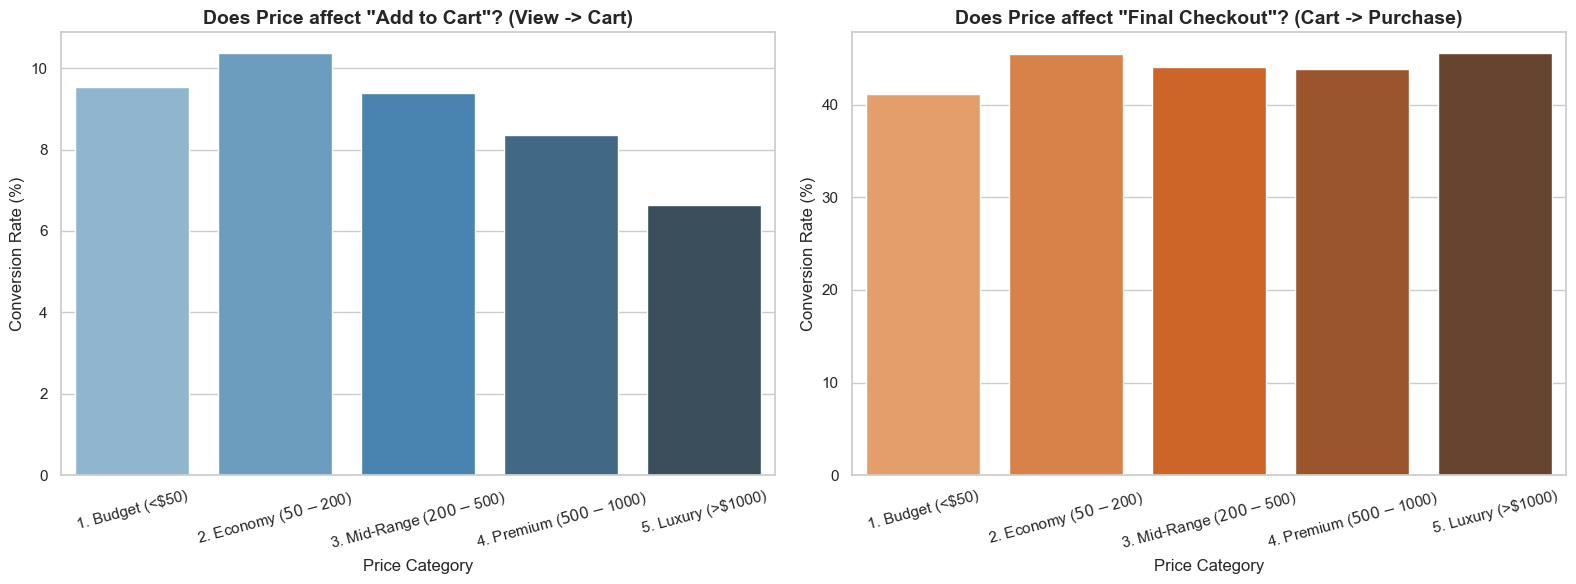

In [36]:
print("🔍 VERIFYING THE 'PRICE vs CONVERSION' HYPOTHESIS...")
# STEP 1: Price ko 5 logical Buckets (Categories) mein baatna
price_bins = [0, 50, 200, 500, 1000, final_df['price'].max()]
bin_labels = ['1. Budget (<$50)', '2. Economy ($50-$200)', '3. Mid-Range ($200-$500)', '4. Premium ($500-$1000)', '5. Luxury (>$1000)']

# Ek copy bana rahe hain taaki original data safe rahe
funnel_df = final_df.copy()
funnel_df['price_bucket'] = pd.cut(funnel_df['price'], bins=price_bins, labels=bin_labels)

# STEP 2: Har Price Bucket mein kitne views, carts, aur purchases hue?
funnel_stats = funnel_df.groupby(['price_bucket', 'event_type'])['user_session'].nunique().unstack(fill_value=0)

# STEP 3: Conversion Rates Calculate Karna
# 1. Dekhne walo mein se kitno ne cart mein daala?
funnel_stats['View_to_Cart_Rate (%)'] = (funnel_stats['cart'] / funnel_stats['view']) * 100

# 2. Cart mein daalne walo mein se kitno ne khareeda?
funnel_stats['Cart_to_Purchase_Rate (%)'] = (funnel_stats['purchase'] / funnel_stats['cart']) * 100

# 3. Overall (Dekhne walo mein se kitno ne khareeda?)
funnel_stats['Overall_Conversion (%)'] = (funnel_stats['purchase'] / funnel_stats['view']) * 100

print("\n📊 THE PRICE FUNNEL REALITY:")
display(funnel_stats[['View_to_Cart_Rate (%)', 'Cart_to_Purchase_Rate (%)', 'Overall_Conversion (%)']].round(2))
# STEP 4: Isko Graph par dekhna taaki crystal clear ho jaye
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Graph A: View to Cart Drop-off
sns.barplot(x=funnel_stats.index, y=funnel_stats['View_to_Cart_Rate (%)'], palette="Blues_d", ax=axes[0])
axes[0].set_title('Does Price affect "Add to Cart"? (View -> Cart)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price Category', fontsize=12)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].tick_params(axis='x', rotation=15)
# Graph B: Cart to Purchase Drop-off
sns.barplot(x=funnel_stats.index, y=funnel_stats['Cart_to_Purchase_Rate (%)'], palette="Oranges_d", ax=axes[1])
axes[1].set_title('Does Price affect "Final Checkout"? (Cart -> Purchase)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Price Category', fontsize=12)
axes[1].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_21396\2283856147.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=funnel_stats.index, y=funnel_stats['Overall_Conversion (%)'], palette="Purples_d")


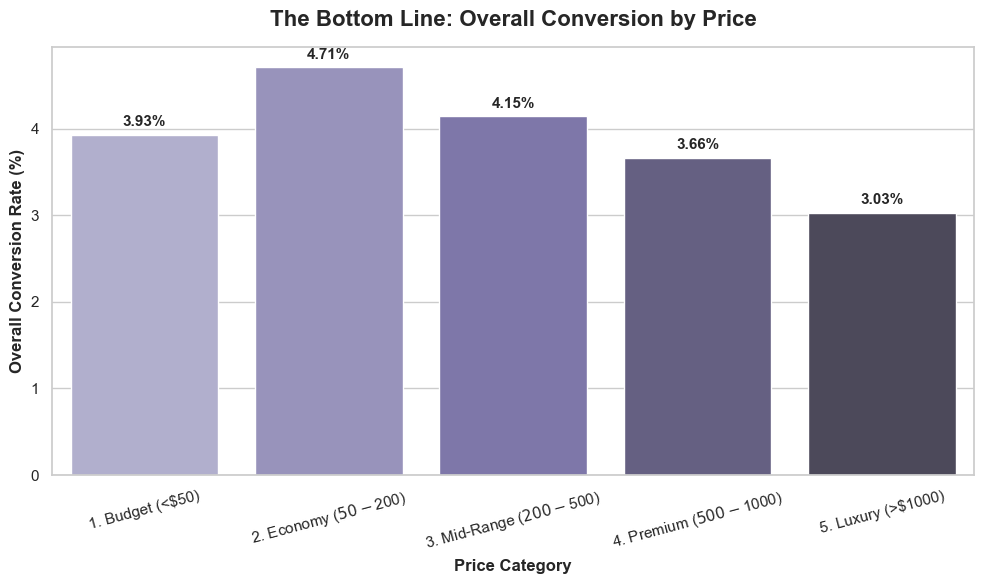

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph C: Overall Conversion Rate (End-to-End Success)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=funnel_stats.index, y=funnel_stats['Overall_Conversion (%)'], palette="Purples_d")

# Graph ko thoda sundar aur readable banane ke liye
plt.title('The Bottom Line: Overall Conversion by Price', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Price Category', fontsize=12, fontweight='bold')
plt.ylabel('Overall Conversion Rate (%)', fontsize=12, fontweight='bold')
plt.xticks(rotation=15)

# Bars ke upar exact percentage likhne ke liye
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [38]:
funnel_stats

event_type,cart,purchase,view,View_to_Cart_Rate (%),Cart_to_Purchase_Rate (%),Overall_Conversion (%)
price_bucket,,,,,,
1. Budget (<$50),33532,13826,351538,9.538656,41.232256,3.933003
2. Economy ($50-$200),69686,31679,672549,10.361476,45.459633,4.710289
3. Mid-Range ($200-$500),48836,21555,519995,9.391629,44.137522,4.145232
4. Premium ($500-$1000),23387,10256,279844,8.357156,43.853423,3.664899
5. Luxury (>$1000),9062,4129,136364,6.645449,45.563893,3.027925


Box-Plot

🎨 Generating the View -> Cart -> Purchase Boxplots...


C:\Users\asus\AppData\Local\Temp\ipykernel_21396\2743336644.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\asus\AppData\Local\Temp\ipykernel_21396\2743336644.py:26: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


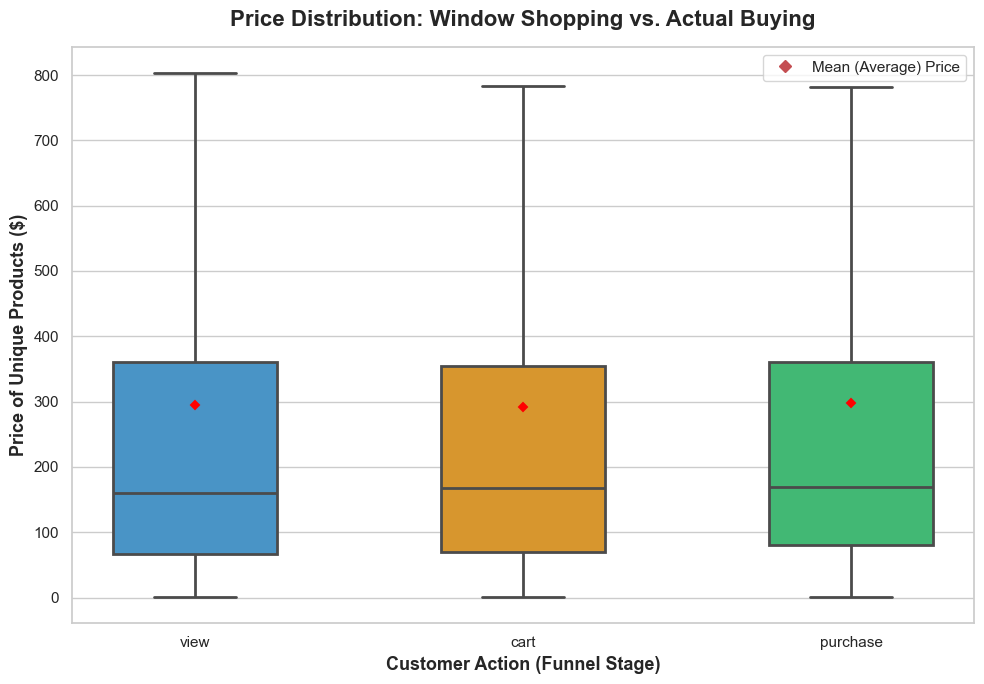


📊 THE EXACT NUMBERS BEHIND THE BOXPLOT (Median Prices):
event_type
view        160.08
cart        167.06
purchase    169.63
Name: price, dtype: float64


In [ ]:
print(" Generating the View -> Cart -> Purchase Boxplots...")

# STEP 1: Har session aur event ke hisaab se Unique Products nikalna
# Isse baar-baar kiye gaye refresh/clicks remove ho jayenge
unique_interactions = final_df.drop_duplicates(subset=['user_session', 'product_id', 'event_type'])

# STEP 2: Graph ki styling setup karna
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

# STEP 3: Boxplot Draw Karna
# showfliers=False karna zaroori hai, warna extreme mehenge products (outliers) 
# graph ke box ko ekdum chota (squash) kar denge.
ax = sns.boxplot(
    data=unique_interactions,
    x='event_type',
    y='price',
    order=['view', 'cart', 'purchase'], # Funnel ke order mein set kiya
    palette={'view': '#3498db', 'cart': '#f39c12', 'purchase': '#2ecc71'},
    showfliers=False, 
    width=0.5,
    linewidth=2
)

# Averages (Means) ko dot ke form mein dikhane ke liye (Optional but powerful)
sns.pointplot(
    data=unique_interactions,
    x='event_type',
    y='price',
    order=['view', 'cart', 'purchase'],
    estimator='mean',
    errorbar=None,
    color='red',
    markers='D',
    scale=0.7,
    linestyles=''
)

# Legend for the Red Dot
plt.plot([], [], 'rD', label='Mean (Average) Price')

# STEP 4: Labels and Titles
plt.title('Price Distribution: Window Shopping vs. Actual Buying', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Customer Action (Funnel Stage)', fontsize=13, fontweight='bold')
plt.ylabel('Price of Unique Products ($)', fontsize=13, fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()

# STEP 5: Parde ke peeche ke exactly numbers print karna
print("\n📊 THE EXACT NUMBERS BEHIND THE BOXPLOT (Median Prices):")
stats_df = unique_interactions.groupby('event_type')['price'].median().reindex(['view', 'cart', 'purchase'])
print(stats_df)

🔍 RUNNING DELUSION-FREE BOXPLOT ANALYSIS...


C:\Users\asus\AppData\Local\Temp\ipykernel_21396\3687686287.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\asus\AppData\Local\Temp\ipykernel_21396\3687686287.py:32: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(


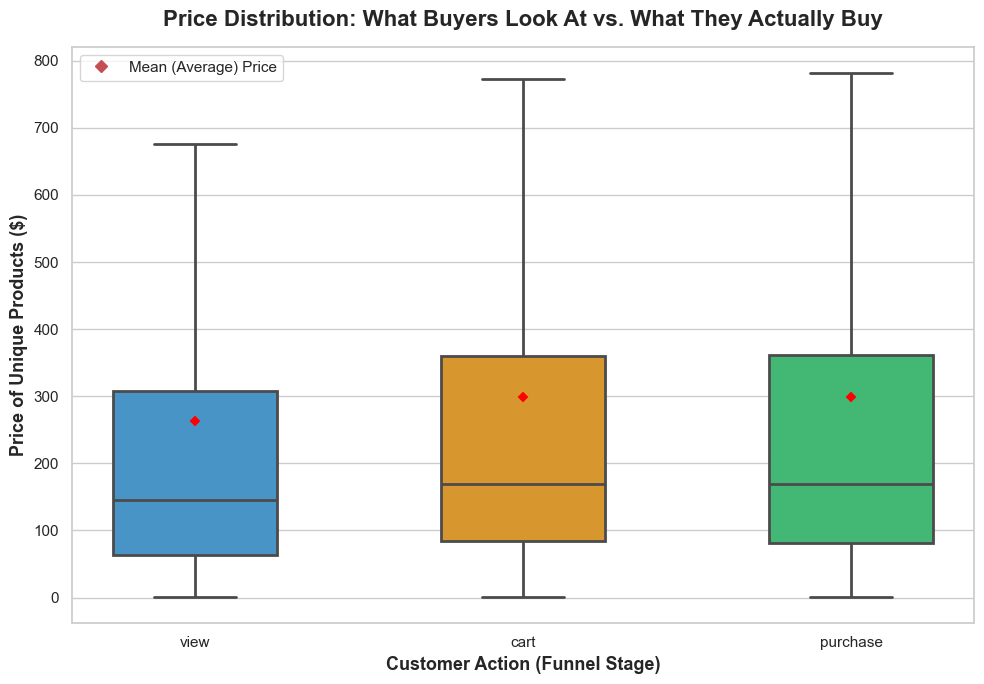


📊 THE EXACT NUMBERS (Buyers Only):

--- MEDIAN PRICES ---
event_type
view        145.88
cart        169.89
purchase    169.63
Name: price, dtype: float64

--- MEAN (RED DOT) PRICES ---
event_type
view        263.78
cart        298.29
purchase    298.30
Name: price, dtype: float64


In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("🔍 RUNNING DELUSION-FREE BOXPLOT ANALYSIS...")

# STEP 1: Sirf un 'user_session' ko identify karein jinhone actual mein purchase ki hai
purchasers = final_df[final_df['event_type'] == 'purchase']['user_session'].unique()

# STEP 2: Ab sirf un Buyers ka poora history (Views, Carts, Purchases) filter karein
buyers_data = final_df[final_df['user_session'].isin(purchasers)]

# STEP 3: Har session aur event ke hisaab se Unique Products nikalna
# (Aapka purana step, jo bilkul sahi tha)
unique_interactions = buyers_data.drop_duplicates(subset=['user_session', 'product_id', 'event_type'])

# --- BAAKI KA GRAPH CODE SAME RAHEGA ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 7))

ax = sns.boxplot(
    data=unique_interactions,
    x='event_type',
    y='price',
    order=['view', 'cart', 'purchase'],
    palette={'view': '#3498db', 'cart': '#f39c12', 'purchase': '#2ecc71'},
    showfliers=False, 
    width=0.5,
    linewidth=2
)

sns.pointplot(
    data=unique_interactions,
    x='event_type',
    y='price',
    order=['view', 'cart', 'purchase'],
    estimator='mean',
    errorbar=None,
    color='red',
    markers='D',
    scale=0.7,
    linestyles=''
)

# Legend and Labels
plt.plot([], [], 'rD', label='Mean (Average) Price')
plt.title('Price Distribution: What Buyers Look At vs. What They Actually Buy', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Customer Action (Funnel Stage)', fontsize=13, fontweight='bold')
plt.ylabel('Price of Unique Products ($)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Exact Numbers
print("\n📊 THE EXACT NUMBERS (Buyers Only):")
print("\n--- MEDIAN PRICES ---")
print(unique_interactions.groupby('event_type')['price'].median().reindex(['view', 'cart', 'purchase']))
print("\n--- MEAN (RED DOT) PRICES ---")
print(unique_interactions.groupby('event_type')['price'].mean().reindex(['view', 'cart', 'purchase']).round(2))

In [29]:
ml_dataframe=pd.read_csv('ml_dataframe_clipped_with_new_columns_median_view_Price.csv')

In [30]:
ml_dataframe.head(3)

,total_views,total_carts,unique_products,avg_view_price,median_view_price,avg_cart_price,target_purchase,session_duration_seconds,views_per_minute,first_cart_time_seconds
0,1,0,1,69.170000,69.17,0.0,0,0.0,60.000000,0.0
1,9,0,5,822.974444,716.76,0.0,0,485.0,1.111111,0.0
2,1,0,1,10.180000,10.18,0.0,0,0.0,60.000000,0.0


In [31]:
import scipy.stats as stats
import numpy as np

print("🧪 RUNNING ANOVA TEST: Does Price Separate Buyers from Non-Buyers?")

# STEP 1: Data ko do hisso mein todna (Target = 1 vs Target = 0)
# Hum hamara best price feature 'median_view_price' use kar rahe hain
buyers_price = ml_dataframe[ml_dataframe['target_purchase'] == 1]['median_view_price']
non_buyers_price = ml_dataframe[ml_dataframe['target_purchase'] == 0]['median_view_price']

# STEP 2: The One-Way ANOVA Test
# Null Hypothesis (H0): Buyers aur Non-Buyers ke price mein koi farq nahi hai.
# Alternate Hypothesis (H1): Dono ke price mein farq hai.
f_stat, p_value = stats.f_oneway(non_buyers_price, buyers_price)

print("\n" + "="*60)
print("📊 1. THE P-VALUE TEST (Mathematical Significance)")
print("="*60)
print(f"-> F-Statistic: {f_stat:.4f}")
print(f"-> P-Value:     {p_value:.10f}")

alpha = 0.05
if p_value < alpha:
    print("\n🚨 RESULT: REJECT the Null Hypothesis.")
    print("Conclusion: Mathematically, dono groups ke prices alag hain (Due to large data size).")
else:
    print("\n✅ RESULT: FAIL TO REJECT the Null Hypothesis.")
    print("Conclusion: Mathematically, dono groups ke prices bilkul same hain.")


# STEP 3: The "Senior Data Scientist" Reality Check (Effect Size - Eta Squared)
# Formula: Sum of Squares Between / Sum of Squares Total
print("\n" + "="*60)
print("🧠 2. THE EFFECT SIZE (Practical Significance / Eta-Squared)")
print("="*60)

mean_all = ml_dataframe['median_view_price'].mean()
ss_total = np.sum((ml_dataframe['median_view_price'] - mean_all)**2)

mean_buyers = buyers_price.mean()
mean_non_buyers = non_buyers_price.mean()

# SS Between = N_buyers * (mean_buyers - overall_mean)^2 + N_non_buyers * (mean_non_buyers - overall_mean)^2
ss_between = (len(buyers_price) * (mean_buyers - mean_all)**2) + (len(non_buyers_price) * (mean_non_buyers - mean_all)**2)

eta_squared = ss_between / ss_total
impact_percentage = eta_squared * 100

print(f"-> Eta-Squared Value: {eta_squared:.6f}")
print(f"-> Impact Percentage: {impact_percentage:.4f}%\n")

print("💡 FINAL INTERVIEW INSIGHT:")
if impact_percentage < 1.0:
    print(f"Even though P-value might reject the null hypothesis, the price variance ONLY explains {impact_percentage:.4f}% of the reason why a user purchases!")
    print("THIS IS EXACTLY WHY XGBOOST & EFS DROPPED THE PRICE FEATURE! 🤯")
else:
    print(f"Price explains {impact_percentage:.4f}% of the buying decision. It is a useful feature.")

🧪 RUNNING ANOVA TEST: Does Price Separate Buyers from Non-Buyers?

📊 1. THE P-VALUE TEST (Mathematical Significance)
-> F-Statistic: 67.4498
-> P-Value:     0.0000000000

🚨 RESULT: REJECT the Null Hypothesis.
Conclusion: Mathematically, dono groups ke prices alag hain (Due to large data size).

🧠 2. THE EFFECT SIZE (Practical Significance / Eta-Squared)
-> Eta-Squared Value: 0.000049
-> Impact Percentage: 0.0049%

💡 FINAL INTERVIEW INSIGHT:
Even though P-value might reject the null hypothesis, the price variance ONLY explains 0.0049% of the reason why a user purchases!
THIS IS EXACTLY WHY XGBOOST & EFS DROPPED THE PRICE FEATURE! 🤯


STRIP_PLOT:-

In [33]:
ml_dataframe.head(5)

,total_views,total_carts,unique_products,avg_view_price,median_view_price,avg_cart_price,target_purchase,session_duration_seconds,views_per_minute,first_cart_time_seconds
0,1,0,1,69.170000,69.17,0.0,0,0.0,60.000000,0.0
1,9,0,5,822.974444,716.76,0.0,0,485.0,1.111111,0.0
2,1,0,1,10.180000,10.18,0.0,0,0.0,60.000000,0.0
3,6,0,3,362.676667,362.76,0.0,0,133.0,2.686567,0.0
4,2,0,1,127.150000,127.15,0.0,0,56.0,2.105263,0.0


🎨 Generating Categorical Scatterplots (Strip Plots) - Seaborn Updated...


C:\Users\asus\AppData\Local\Temp\ipykernel_5892\4141572487.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Not Purchased (0)', 'Purchased (1)'], fontsize=12, fontweight='bold')
C:\Users\asus\AppData\Local\Temp\ipykernel_5892\4141572487.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Not Purchased (0)', 'Purchased (1)'], fontsize=12, fontweight='bold')


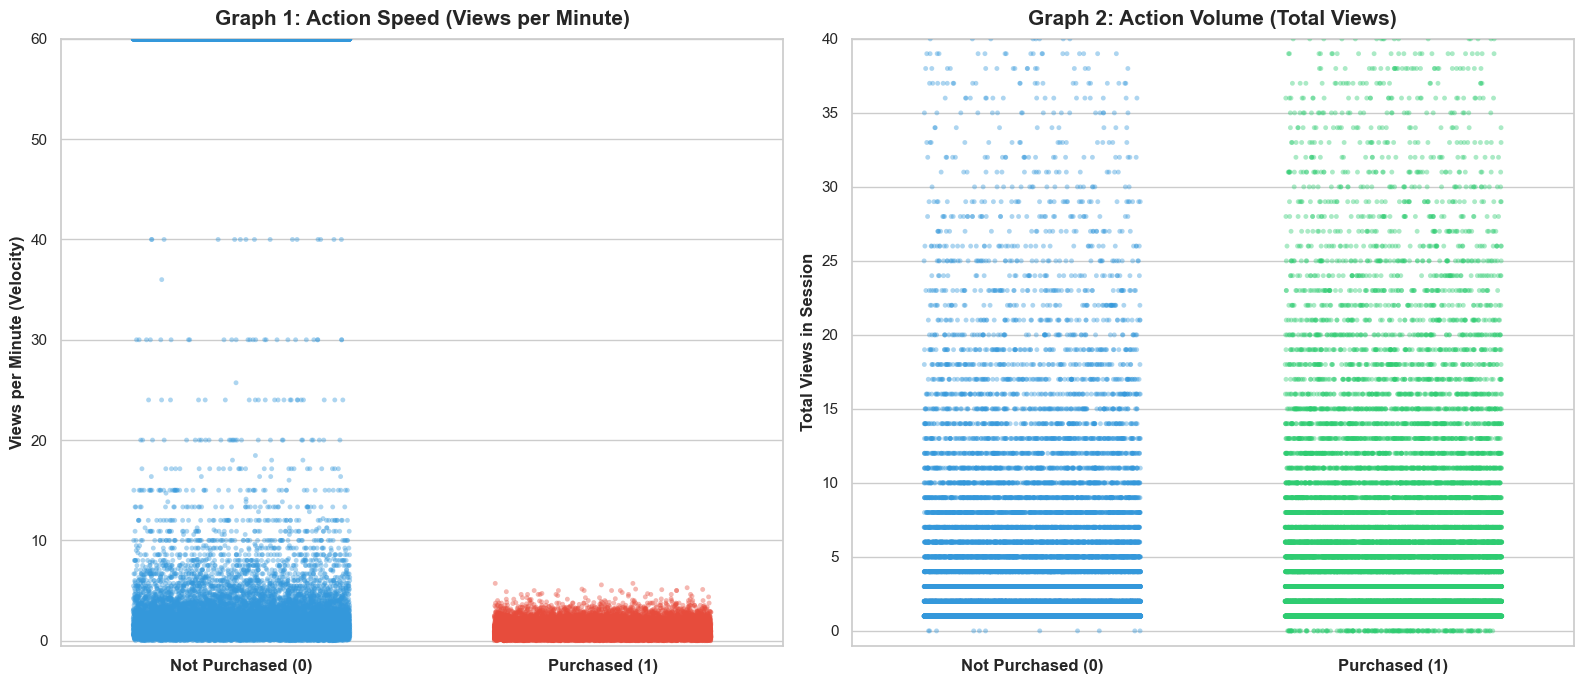

In [35]:


print("🎨 Generating Categorical Scatterplots (Strip Plots) - Seaborn Updated...")

# STEP 1: THE BULLETPROOF SAMPLING (Stratified)
buyers_df = ml_dataframe[ml_dataframe['target_purchase'] == 1]
non_buyers_df = ml_dataframe[ml_dataframe['target_purchase'] == 0]

buyers_sample = buyers_df.sample(n=min(len(buyers_df), 25000), random_state=42)
non_buyers_sample = non_buyers_df.sample(n=min(len(non_buyers_df), 25000), random_state=42)

sample_df = pd.concat([buyers_sample, non_buyers_sample]).reset_index()

# Seaborn ke naye version ke liye target ko explicitly string bana dete hain taaki koi confusion na ho
sample_df['target_purchase_str'] = sample_df['target_purchase'].astype(str)

limit_vpm = sample_df['views_per_minute'].quantile(0.99)
limit_tv = sample_df['total_views'].quantile(0.99)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- GRAPH 1: VIEWS PER MINUTE (SPEED) vs PURCHASE ---
sns.stripplot(
    data=sample_df, 
    x='target_purchase_str',  # String wala column use kiya
    y='views_per_minute', 
    hue='target_purchase_str', # Naye Seaborn ke liye hue zaroori hai
    palette={'0': '#3498db', '1': '#e74c3c'}, # Keys ab explicitly strings hain
    legend=False,             # Warning hatane ke liye
    alpha=0.4, 
    jitter=0.3, 
    size=3.5, 
    ax=axes[0],
    order=['0', '1']          # Order fix kar diya
)
axes[0].set_title('Graph 1: Action Speed (Views per Minute)', fontsize=15, fontweight='bold', pad=10)
axes[0].set_xticklabels(['Not Purchased (0)', 'Purchased (1)'], fontsize=12, fontweight='bold')
axes[0].set_ylabel('Views per Minute (Velocity)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylim(-0.5, limit_vpm) 

# --- GRAPH 2: TOTAL VIEWS (VOLUME) vs PURCHASE ---
sns.stripplot(
    data=sample_df, 
    x='target_purchase_str', 
    y='total_views', 
    hue='target_purchase_str',
    palette={'0': '#3498db', '1': '#2ecc71'}, # Keys as strings
    legend=False,
    alpha=0.4, 
    jitter=0.3, 
    size=3.5, 
    ax=axes[1],
    order=['0', '1']
)
axes[1].set_title('Graph 2: Action Volume (Total Views)', fontsize=15, fontweight='bold', pad=10)
axes[1].set_xticklabels(['Not Purchased (0)', 'Purchased (1)'], fontsize=12, fontweight='bold')
axes[1].set_ylabel('Total Views in Session', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylim(-1, limit_tv) 

plt.tight_layout()
plt.show()

## New column as focus Ratio:- 

In [36]:
# 1. Naya option jo aapne socha: Unique options kitni tezi se dekhe
ml_dataframe['unique_per_minute'] = ml_dataframe['unique_products'] / ((ml_dataframe['session_duration_seconds'] + 1) / 60)

# 2. The Golden Feature: Focus Ratio (Kitna obsessively ek hi cheez dekhi)
ml_dataframe['focus_ratio'] = ml_dataframe['total_views'] / ml_dataframe['unique_products']

In [39]:
ml_dataframe.head(4)

,total_views,total_carts,unique_products,avg_view_price,median_view_price,avg_cart_price,target_purchase,session_duration_seconds,views_per_minute,first_cart_time_seconds,unique_per_minute,focus_ratio
0,1,0,1,69.170000,69.17,0.0,0,0.0,60.000000,0.0,60.000000,1.0
1,9,0,5,822.974444,716.76,0.0,0,485.0,1.111111,0.0,0.617284,1.8
2,1,0,1,10.180000,10.18,0.0,0,0.0,60.000000,0.0,60.000000,1.0
3,6,0,3,362.676667,362.76,0.0,0,133.0,2.686567,0.0,1.343284,2.0


In [40]:
ml_dataframe[ml_dataframe['target_purchase']==1]

,total_views,total_carts,unique_products,avg_view_price,median_view_price,avg_cart_price,target_purchase,session_duration_seconds,views_per_minute,first_cart_time_seconds,unique_per_minute,focus_ratio
21,2,0,1,153.670000,153.670,0.00,1,202.0,0.591133,0.0,0.295567,2.000000
23,3,2,1,246.000000,246.000,246.00,1,323.0,0.555556,37.0,0.185185,3.000000
54,1,1,1,211.020000,211.020,211.02,1,186.0,0.320856,26.0,0.320856,1.000000
61,2,1,1,89.810000,89.810,89.81,1,217.0,0.550459,58.0,0.275229,2.000000
81,1,1,1,128.420000,128.420,128.42,1,405.0,0.147783,174.0,0.147783,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
1378165,5,1,4,171.986000,164.850,164.85,1,228.0,1.310044,86.0,1.048035,1.250000
1378172,8,1,2,23.013750,20.050,20.05,1,349.0,1.371429,133.0,0.342857,4.000000
1378204,1,3,1,238.670000,238.670,238.67,1,125.0,0.476190,8.0,0.476190,1.000000
1378215,2,1,1,959.730000,959.730,959.73,1,94.0,1.263158,17.0,0.631579,2.000000


📊 Analyzing 'Focus Ratio' vs 'Purchase Intent'...


C:\Users\asus\AppData\Local\Temp\ipykernel_5892\3462475857.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


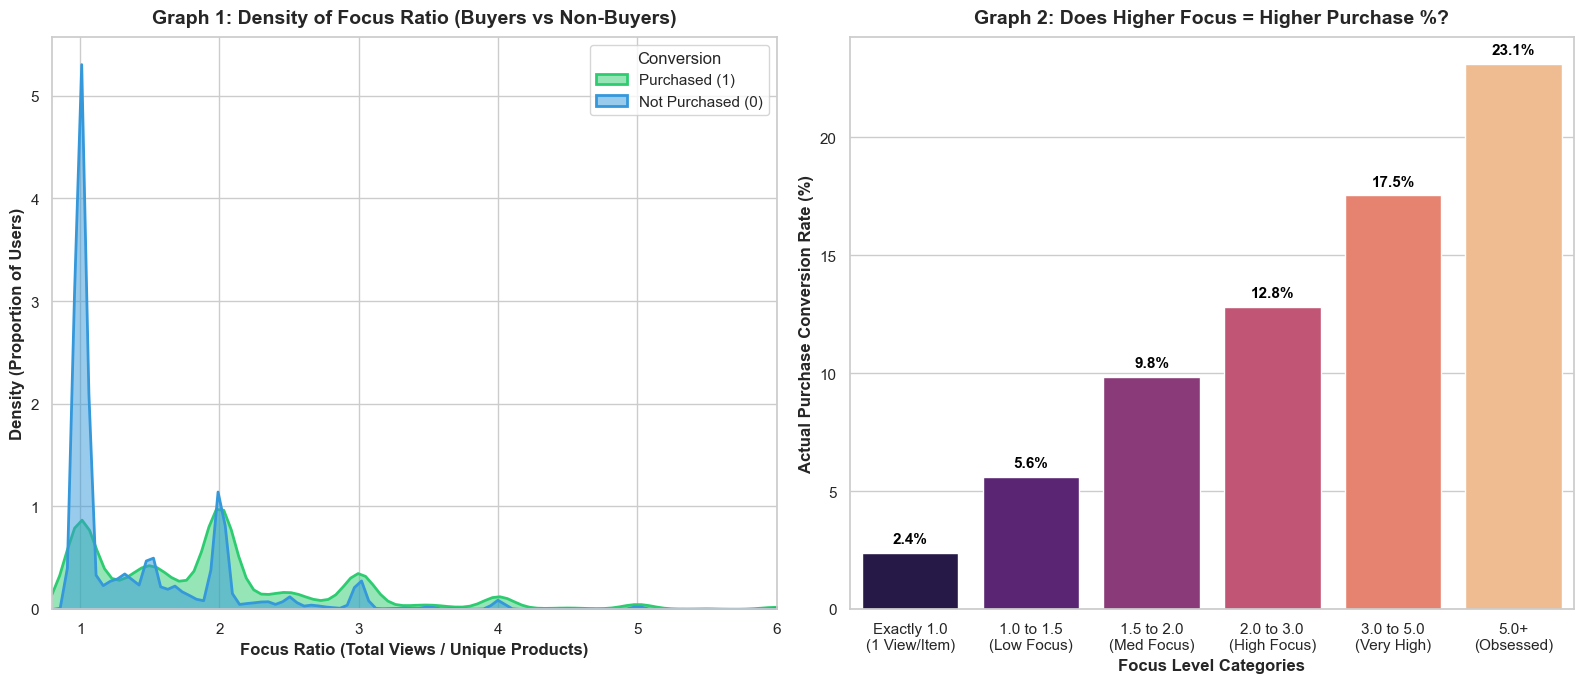

In [41]:

print("📊 Analyzing 'Focus Ratio' vs 'Purchase Intent'...")

# STEP 1: Extreme outliers ko filter karna visualization ke liye (Focus ratio > 10 bohot rare hoga)
# Original data safe rahega, yeh sirf graph ke liye hai
vis_df = ml_dataframe[ml_dataframe['focus_ratio'] <= 10].copy()

# Seaborn version issue se bachne ke liye explicitly target ko string banana
vis_df['target_str'] = vis_df['target_purchase'].astype(str)

# STEP 2: Conversion Rate ke liye Buckets (Categories) banana
# Hum Focus Ratio ko alag-alag levels mein divide kar rahe hain
bins = [0.99, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0]
labels = [
    'Exactly 1.0\n(1 View/Item)', 
    '1.0 to 1.5\n(Low Focus)', 
    '1.5 to 2.0\n(Med Focus)', 
    '2.0 to 3.0\n(High Focus)', 
    '3.0 to 5.0\n(Very High)', 
    '5.0+\n(Obsessed)'
]
vis_df['focus_bucket'] = pd.cut(vis_df['focus_ratio'], bins=bins, labels=labels)

# Calculate Conversion Rate per Bucket
conversion_rates = vis_df.groupby('focus_bucket', observed=True)['target_purchase'].mean() * 100

# STEP 3: Plotting setup
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- GRAPH 1: DENSITY PLOT (Kahan bheed zyada hai?) ---
sns.kdeplot(
    data=vis_df, 
    x='focus_ratio', 
    hue='target_str', 
    palette={'0': '#3498db', '1': '#2ecc71'},
    fill=True, 
    common_norm=False, # Dono curves ko apne apne 100% scale par dikhata hai
    alpha=0.5, 
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title('Graph 1: Density of Focus Ratio (Buyers vs Non-Buyers)', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Focus Ratio (Total Views / Unique Products)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Density (Proportion of Users)', fontsize=12, fontweight='bold')
axes[0].set_xlim(0.8, 6) # Zooming into the most important area
axes[0].legend(title='Conversion', labels=['Purchased (1)', 'Not Purchased (0)'])


# --- GRAPH 2: CONVERSION RATE BY FOCUS LEVEL ---
sns.barplot(
    x=conversion_rates.index, 
    y=conversion_rates.values, 
    palette='magma', 
    ax=axes[1]
)
axes[1].set_title('Graph 2: Does Higher Focus = Higher Purchase %?', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Focus Level Categories', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Purchase Conversion Rate (%)', fontsize=12, fontweight='bold')

# Bar ke upar exact percentage likhna
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_height():.1f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height()), 
                     ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), 
                     textcoords='offset points')

plt.tight_layout()
plt.show()

### Importing ML_DataFrame

In [3]:
ml_dataframe=pd.read_csv('ml_dataframe_clipped_with_medain_view_cart_view_focus_ratio.csv')

📊 Analyzing 'Decisiveness' (Cart-to-View Ratio) vs 'Purchase Intent'...


C:\Users\asus\AppData\Local\Temp\ipykernel_4704\4137379877.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


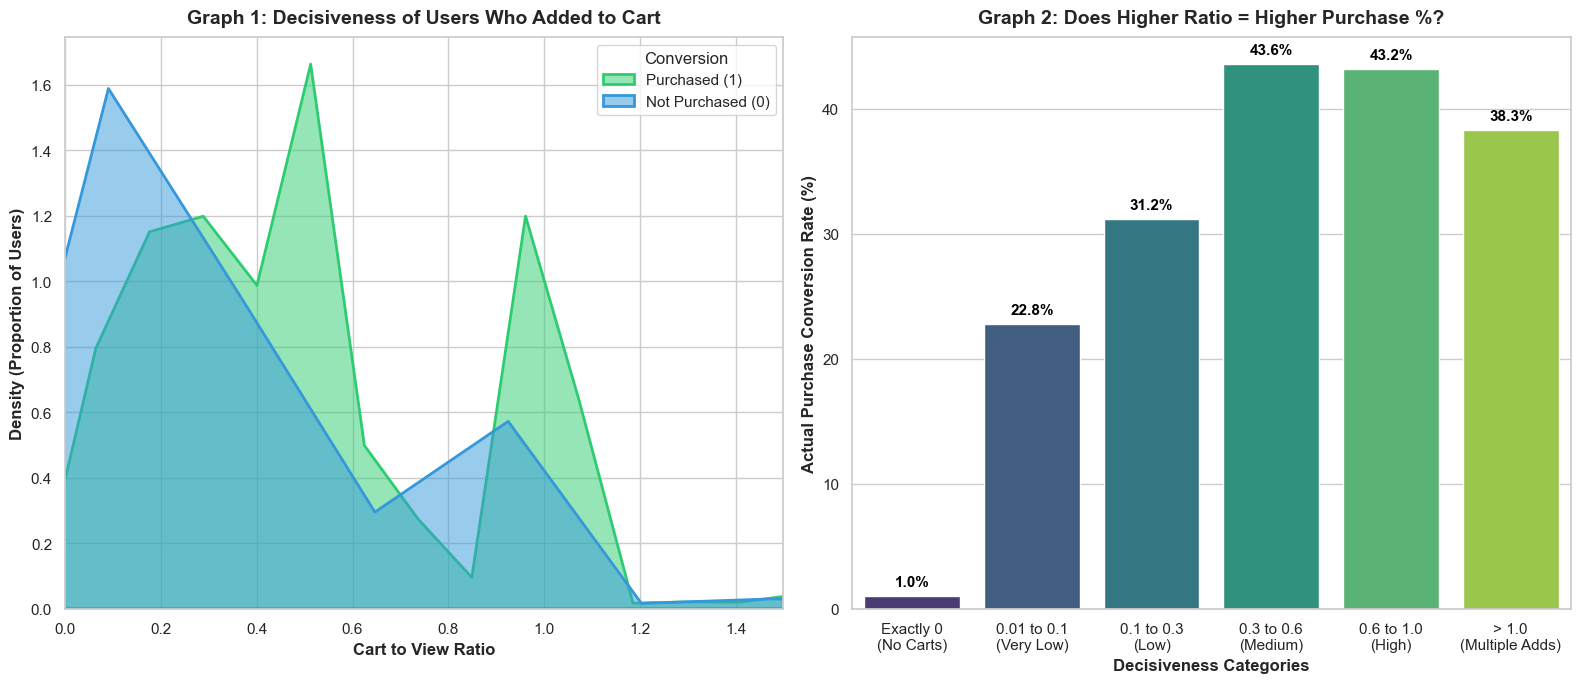

In [4]:


print("📊 Analyzing 'Decisiveness' (Cart-to-View Ratio) vs 'Purchase Intent'...")

# STEP 1: Feature ensure karna (Agar aapne abhi tak nahi banaya tha)
ml_dataframe['cart_to_view_ratio'] = ml_dataframe['total_carts'] / ml_dataframe['total_views'].replace(0, 1)

# Visualization ke liye ek copy banate hain
vis_df = ml_dataframe.copy()
vis_df['target_str'] = vis_df['target_purchase'].astype(str)

# STEP 2: Conversion Rate ke liye Categories (Buckets) banana
# Ratio 0 se lekar 1 (ya usse thoda upar) tak ho sakta hai
bins = [-0.01, 0.0, 0.1, 0.3, 0.6, 1.0, 100.0]
labels = [
    'Exactly 0\n(No Carts)', 
    '0.01 to 0.1\n(Very Low)', 
    '0.1 to 0.3\n(Low)', 
    '0.3 to 0.6\n(Medium)', 
    '0.6 to 1.0\n(High)', 
    '> 1.0\n(Multiple Adds)'
]
vis_df['decisiveness_bucket'] = pd.cut(vis_df['cart_to_view_ratio'], bins=bins, labels=labels)

# Calculate Conversion Rate per Bucket
conversion_rates = vis_df.groupby('decisiveness_bucket', observed=True)['target_purchase'].mean() * 100

# STEP 3: Plotting Setup
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- GRAPH 1: DENSITY PLOT (Kahan bheed zyada hai?) ---
# Note: Hum ratio > 0 walo ko filter kar rahe hain graph ke liye, warna '0' par bohot bada spike aayega jo graph kharab kar dega
sns.kdeplot(
    data=vis_df[vis_df['cart_to_view_ratio'] > 0], 
    x='cart_to_view_ratio', 
    hue='target_str', 
    palette={'0': '#3498db', '1': '#2ecc71'},
    fill=True, 
    common_norm=False, 
    alpha=0.5, 
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title('Graph 1: Decisiveness of Users Who Added to Cart', fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel('Cart to View Ratio', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Density (Proportion of Users)', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1.5)
axes[0].legend(title='Conversion', labels=['Purchased (1)', 'Not Purchased (0)'])


# --- GRAPH 2: CONVERSION RATE BY DECISIVENESS LEVEL ---
sns.barplot(
    x=conversion_rates.index, 
    y=conversion_rates.values, 
    palette='viridis', 
    ax=axes[1]
)
axes[1].set_title('Graph 2: Does Higher Ratio = Higher Purchase %?', fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel('Decisiveness Categories', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Purchase Conversion Rate (%)', fontsize=12, fontweight='bold')

# Bar ke upar exact percentage likhna
for p in axes[1].patches:
    height = p.get_height()
    if not np.isnan(height):
        axes[1].annotate(f"{height:.1f}%", 
                         (p.get_x() + p.get_width() / 2., height), 
                         ha='center', va='bottom', fontsize=11, fontweight='bold', color='black', xytext=(0, 5), 
                         textcoords='offset points')

plt.tight_layout()
plt.show()

In [6]:
final_df.head(5)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19


## First_time_cart_adn_dwell

In [7]:
import pandas as pd
import numpy as np

# 1. Ensure event_time is in datetime format
final_df['event_time'] = pd.to_datetime(final_df['event_time'])

# 2. Get the 'First Cart Time' for each user_session
# Sirf wo sessions filter kar rahe hain jisme kam se kam ek baar cart mein item add hua ho
cart_events = final_df[final_df['event_type'] == 'cart']
first_cart_time = cart_events.groupby('user_session')['event_time'].min().reset_index()
first_cart_time.rename(columns={'event_time': 'first_cart_time'}, inplace=True)

# 3. Get the 'Session End Time' (Last activity in that session)
session_end_time = final_df.groupby('user_session')['event_time'].max().reset_index()
session_end_time.rename(columns={'event_time': 'session_end_time'}, inplace=True)

# 4. Identify which sessions actually resulted in a purchase (Conversion)
purchase_sessions = final_df[final_df['event_type'] == 'purchase']['user_session'].unique()

# 5. Merge everything into a session-level DataFrame
session_df = pd.merge(first_cart_time, session_end_time, on='user_session', how='inner')
session_df['is_purchased'] = session_df['user_session'].isin(purchase_sessions).astype(int)

# 6. Calculate Dwell Time in minutes
session_df['post_cart_dwell_time'] = (session_df['session_end_time'] - session_df['first_cart_time']).dt.total_seconds() / 60.0

# 7. Cap the time to handle outliers (e.g., capping at 60 minutes)
CAP_MINUTES = 60
session_df['post_cart_dwell_time_capped'] = session_df['post_cart_dwell_time'].clip(lower=0, upper=CAP_MINUTES)

# --- CONVERSION RATE ANALYSIS ---

# 8. Create Bins to see the relationship between hesitation time and conversion
bins = [-1, 0.5, 5, 15, 30, CAP_MINUTES]
labels = ['Immediate (<30s)', '0.5 - 5 mins', '5 - 15 mins', '15 - 30 mins', '30+ mins']
session_df['hesitation_bins'] = pd.cut(session_df['post_cart_dwell_time_capped'], bins=bins, labels=labels)

# 9. Calculate Conversion Rate for each bin
conversion_analysis = session_df.groupby('hesitation_bins', observed=False)['is_purchased'].agg(['count', 'mean']).reset_index()
conversion_analysis.rename(columns={'count': 'total_sessions', 'mean': 'conversion_rate'}, inplace=True)

# Format the output for better readability
conversion_analysis['conversion_rate'] = (conversion_analysis['conversion_rate'] * 100).round(2).astype(str) + '%'

print(conversion_analysis)

    hesitation_bins  total_sessions conversion_rate
0  Immediate (<30s)           49055            7.3%
1      0.5 - 5 mins           81528          53.77%
2       5 - 15 mins           28819          44.55%
3      15 - 30 mins            8384          34.46%
4          30+ mins            6250          28.74%


C:\Users\asus\AppData\Local\Temp\ipykernel_4704\1926712627.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='budget_bins', y='conversion_rate_pct', data=conversion_by_budget, palette='magma')


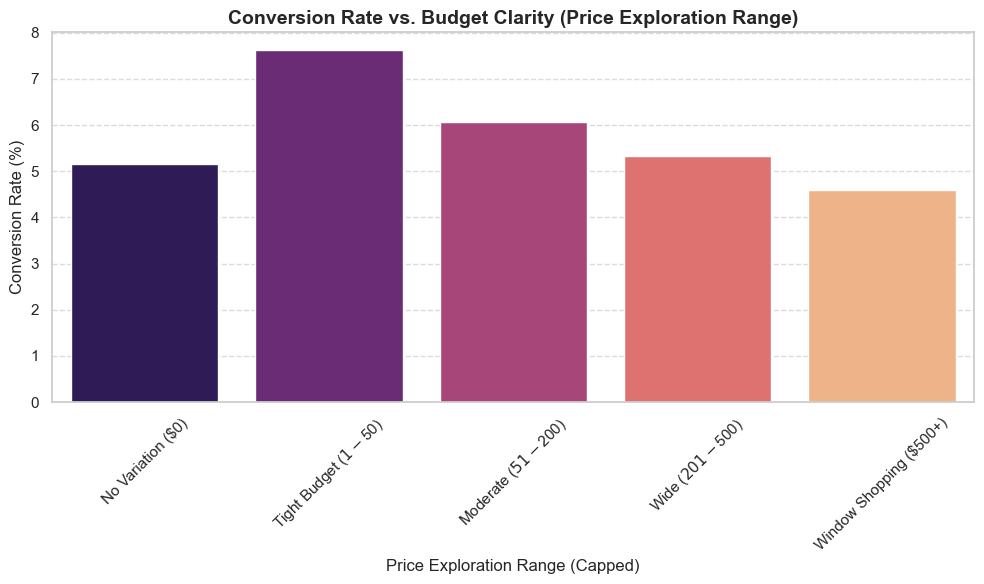

In [8]:
# 1. Sirf 'view' events ko filter karein kyunki hum viewing price range nikal rahe hain
view_events = final_df[final_df['event_type'] == 'view']

# 2. Har session ke liye Max aur Min price calculate karein
price_stats = view_events.groupby('user_session')['price'].agg(['max', 'min']).reset_index()
price_stats.rename(columns={'max': 'max_view_price', 'min': 'min_view_price'}, inplace=True)

# 3. Formula: Range = Max_View_Price - Min_View_Price
price_stats['price_exploration_range'] = price_stats['max_view_price'] - price_stats['min_view_price']

# 4. Outliers hatane ke liye Price Range ko Cap karein (e.g., max $1000)
CAP_PRICE = 1000 
price_stats['capped_price_range'] = price_stats['price_exploration_range'].clip(upper=CAP_PRICE)

# 5. Purchase sessions identify karein (agar pehle wale code se nahi hai toh)
purchase_sessions = final_df[final_df['event_type'] == 'purchase']['user_session'].unique()
price_stats['is_purchased'] = price_stats['user_session'].isin(purchase_sessions).astype(int)

# 6. Graph ke liye Bins create karein
bins = [-1, 0, 50, 200, 500, CAP_PRICE]
labels = ['No Variation ($0)', 'Tight Budget ($1-$50)', 'Moderate ($51-$200)', 'Wide ($201-$500)', 'Window Shopping ($500+)']
price_stats['budget_bins'] = pd.cut(price_stats['capped_price_range'], bins=bins, labels=labels)

# 7. Conversion Rate calculate karein
conversion_by_budget = price_stats.groupby('budget_bins', observed=False)['is_purchased'].mean().reset_index()
conversion_by_budget['conversion_rate_pct'] = conversion_by_budget['is_purchased'] * 100

# 8. Graph Plot Karein
plt.figure(figsize=(10, 6))
sns.barplot(x='budget_bins', y='conversion_rate_pct', data=conversion_by_budget, palette='magma')

plt.title('Conversion Rate vs. Budget Clarity (Price Exploration Range)', fontsize=14, fontweight='bold')
plt.xlabel('Price Exploration Range (Capped)', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()